# Accesibilidad territorial a los servicios de salud de San Miguel

Análisis geoespacial de la proximidad de la población del partido de San Miguel
(Buenos Aires, Argentina) a la red municipal de salud.

**Año de referencia de los datos:** Censo 2022  
**Fecha de realización:** octubre de 2026

## Reproducibilidad

Este notebook es una versión ordenada del cuaderno utilizado durante el análisis.
Conserva el código del proyecto y elimina los resultados almacenados para facilitar
su publicación y revisión en GitHub.

### Archivos de entrada

Colocar los siguientes archivos en el directorio de trabajo antes de ejecutar:

- `radios_san_miguel.geojson`: radios censales del Geoportal de la Municipalidad de San Miguel.
- `radios2022_envejecimiento.gpkg`: base geoespacial con información demográfica derivada del Censo 2022.
- `cobertura_salud.xlsx`: extracción de cobertura de salud realizada mediante REDATAM.

Los establecimientos de salud se consultan desde el servicio ArcGIS del Geoportal
municipal y la red vial se obtiene de OpenStreetMap mediante OSMnx.

### Dependencias principales

`pandas`, `numpy`, `geopandas`, `matplotlib`, `mapclassify`, `osmnx`,
`networkx`, `shapely` y `scipy`.


## 1. Carga y preparación de datos

Carga de la cartografía municipal de radios censales.


   objectid      clave provincia partido localidad fraccion radio  \
0       184  067602109        06     760       010       21    09   
1       116  067600111        06     760       010       01    11   
2        87  067601303        06     760       010       13    03   
3       273  067600502        06     760       010       05    02   
4        51  067603401        06     760       010       34    01   

   tot_manzanas  barrio_codigo      barrio_nombre circuito  st_area(shape)  \
0             6             31        Muniz Norte      400    84608.660250   
1             5             28           Belgrano      397   119739.512520   
2             6             35           Obligado      402    80083.196618   
3            11             41  Bella Vista Norte     401a   134504.102851   
4            14              9        San Antonio     397b    94705.858500   

   st_length(shape)                                           geometry  
0       1183.702698  POLYGON ((-58.69752 -3

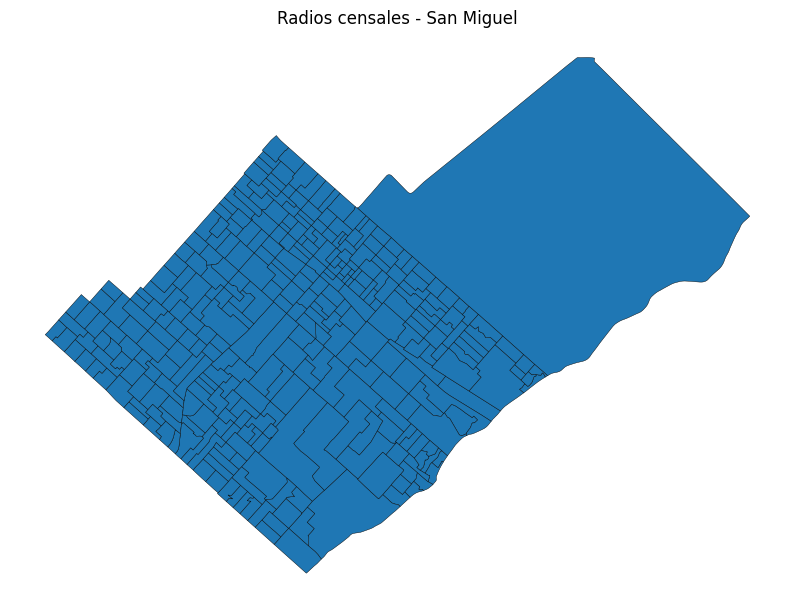

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Leer GeoJSON
radios = gpd.read_file("radios_san_miguel.geojson")

print(radios.head())
print(radios.columns)
print(radios.crs)

# Dibujar radios censales
radios.plot(
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3
)

plt.title("Radios censales - San Miguel")
plt.axis("off")
plt.show()

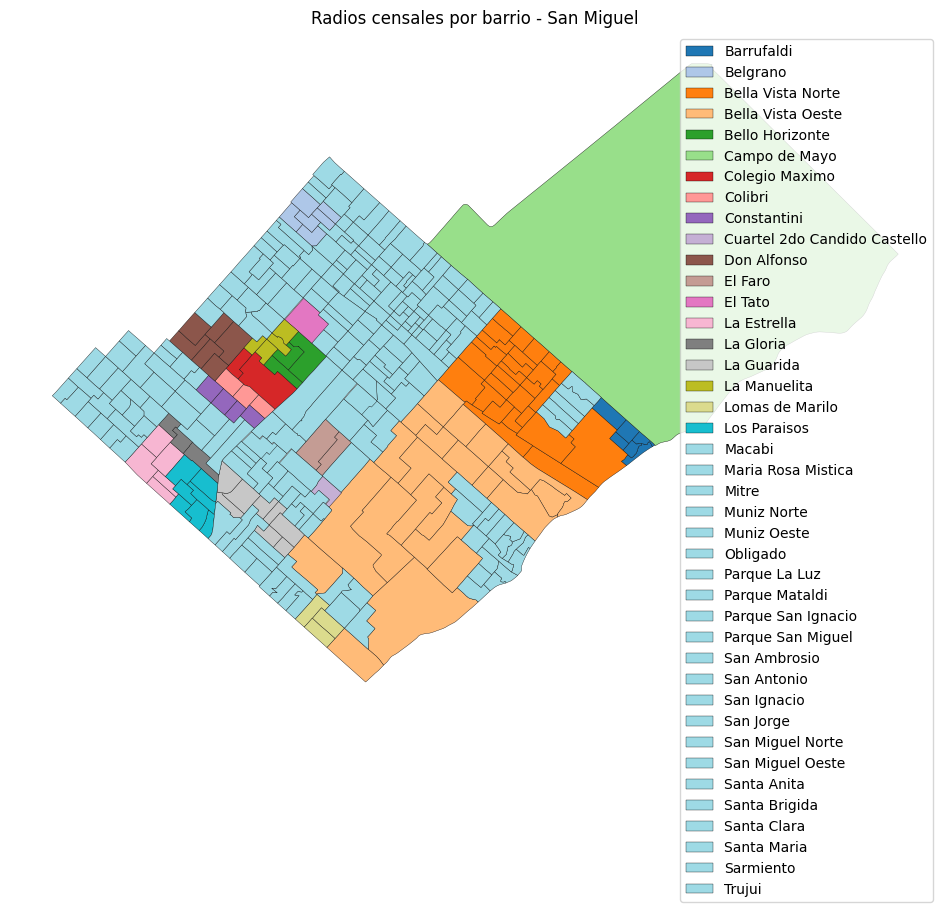

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

radios.plot(
    ax=ax,
    column="barrio_nombre",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.25
)

ax.set_title("Radios censales por barrio - San Miguel")
ax.axis("off")

plt.show()

### 1.1 Datos demográficos por radio censal

Carga y filtrado de la base demográfica para el partido de San Miguel.


In [4]:
import geopandas as gpd

archivo = "radios2022_envejecimiento.gpkg"

radios2022 = gpd.read_file(archivo)

print(radios2022.shape)
print(radios2022.columns)
print(radios2022.crs)

radios2022.head()

(53879, 15)
Index(['NOMPROV', 'NOMDEPTO', 'cat', 'pob0a14a', 'pobMas65a', 'porc0a14a',
       'porc14a65a', 'porcMas65a', 'CRO', 'CA3', 'areaHa', 'densHabHa',
       'pob14a65a', 'indEnv', 'geometry'],
      dtype='object')
EPSG:4326


,NOMPROV,NOMDEPTO,cat,pob0a14a,pobMas65a,porc0a14a,porc14a65a,porcMas65a,CRO,CA3,areaHa,densHabHa,pob14a65a,indEnv,geometry
0,Chaco,General Güemes,1,144,24,"31,72","63,00","5,00",220630510,454,48.39,9.38,286.0,16.67,"MULTIPOLYGON (((-62.3422 -24.12113, -62.34135 ..."
1,Chaco,General Güemes,1,221,17,"40,55","56,33","3,00",220630511,545,69.81,7.81,307.0,7.69,"MULTIPOLYGON (((-62.15305 -24.21878, -62.15193..."
2,Chaco,General Güemes,1,181,31,"32,32","62,14","6,00",220630512,560,101.52,5.52,348.0,17.13,"MULTIPOLYGON (((-61.90156 -24.30404, -61.89786..."
3,Chaco,General Güemes,2,216,54,"23,82","70,23","6,00",220630508,907,77.89,11.64,637.0,25.00,"MULTIPOLYGON (((-61.68305 -24.41869, -61.67586..."
4,Chaco,General Güemes,1,235,23,"29,97","67,09","3,00",220630509,784,52.19,15.02,526.0,9.79,"MULTIPOLYGON (((-61.69002 -24.42233, -61.68918..."


In [5]:
radios2022.columns.tolist()

['NOMPROV',
 'NOMDEPTO',
 'cat',
 'pob0a14a',
 'pobMas65a',
 'porc0a14a',
 'porc14a65a',
 'porcMas65a',
 'CRO',
 'CA3',
 'areaHa',
 'densHabHa',
 'pob14a65a',
 'indEnv',
 'geometry']

In [6]:
radios2022.head()

,NOMPROV,NOMDEPTO,cat,pob0a14a,pobMas65a,porc0a14a,porc14a65a,porcMas65a,CRO,CA3,areaHa,densHabHa,pob14a65a,indEnv,geometry
0,Chaco,General Güemes,1,144,24,"31,72","63,00","5,00",220630510,454,48.39,9.38,286.0,16.67,"MULTIPOLYGON (((-62.3422 -24.12113, -62.34135 ..."
1,Chaco,General Güemes,1,221,17,"40,55","56,33","3,00",220630511,545,69.81,7.81,307.0,7.69,"MULTIPOLYGON (((-62.15305 -24.21878, -62.15193..."
2,Chaco,General Güemes,1,181,31,"32,32","62,14","6,00",220630512,560,101.52,5.52,348.0,17.13,"MULTIPOLYGON (((-61.90156 -24.30404, -61.89786..."
3,Chaco,General Güemes,2,216,54,"23,82","70,23","6,00",220630508,907,77.89,11.64,637.0,25.00,"MULTIPOLYGON (((-61.68305 -24.41869, -61.67586..."
4,Chaco,General Güemes,1,235,23,"29,97","67,09","3,00",220630509,784,52.19,15.02,526.0,9.79,"MULTIPOLYGON (((-61.69002 -24.42233, -61.68918..."


In [7]:
san_miguel = radios2022[
    (radios2022["NOMPROV"] == "Buenos Aires") &
    (radios2022["NOMDEPTO"] == "San Miguel")
].copy()

print(san_miguel.shape)
san_miguel.head()

(326, 15)


,NOMPROV,NOMDEPTO,cat,pob0a14a,pobMas65a,porc0a14a,porc14a65a,porcMas65a,CRO,CA3,areaHa,densHabHa,pob14a65a,indEnv,geometry
1469,Buenos Aires,San Miguel,3,169,98,"24,01","62,07","14,00",067603004,704,22.67,31.06,437.0,57.99,"MULTIPOLYGON (((-58.74067 -34.5779, -58.74036 ..."
1473,Buenos Aires,San Miguel,4,203,122,"20,97","66,43","13,00",067601106,968,16.19,59.79,643.0,60.10,"MULTIPOLYGON (((-58.7379 -34.54408, -58.73677 ..."
1595,Buenos Aires,San Miguel,3,291,169,"20,83","67,07","12,00",067601901,1397,20.24,69.03,937.0,58.08,"MULTIPOLYGON (((-58.71174 -34.52525, -58.7109 ..."
1622,Buenos Aires,San Miguel,4,155,97,"21,03","65,81","13,00",067600902,737,14.07,52.39,485.0,62.58,"MULTIPOLYGON (((-58.72814 -34.53235, -58.72711..."
1623,Buenos Aires,San Miguel,2,184,51,"21,83","72,12","6,00",067602510,843,21.64,38.96,608.0,27.72,"MULTIPOLYGON (((-58.72887 -34.54404, -58.73013..."


In [8]:
san_miguel[
    ["pob0a14a", "pob14a65a", "pobMas65a"]
].dtypes

,0
pob0a14a,object
pob14a65a,float64
pobMas65a,object


In [9]:
import pandas as pd

columnas_poblacion = [
    "pob0a14a",
    "pob14a65a",
    "pobMas65a"
]

for col in columnas_poblacion:
    san_miguel[col] = pd.to_numeric(
        san_miguel[col],
        errors="coerce"
    )

In [10]:
san_miguel[columnas_poblacion].isna().sum()

,0
pob0a14a,0
pob14a65a,0
pobMas65a,0


In [11]:
san_miguel["poblacion"] = (
    san_miguel["pob0a14a"] +
    san_miguel["pob14a65a"] +
    san_miguel["pobMas65a"]
)

print("Radios censales:", len(san_miguel))
print("Población total:", san_miguel["poblacion"].sum())

san_miguel[
    ["CRO", "poblacion", "densHabHa",
     "pob0a14a", "pob14a65a", "pobMas65a"]
].head()

Radios censales: 326
Población total: 326091.0


,CRO,poblacion,densHabHa,pob0a14a,pob14a65a,pobMas65a
1469,067603004,704.0,31.06,169,437.0,98
1473,067601106,968.0,59.79,203,643.0,122
1595,067601901,1397.0,69.03,291,937.0,169
1622,067600902,737.0,52.39,155,485.0,97
1623,067602510,843.0,38.96,184,608.0,51


In [12]:
print("Cantidad de radios:", len(san_miguel))
print("Población total calculada:", san_miguel["poblacion"].sum())

Cantidad de radios: 326
Población total calculada: 326091.0


In [13]:
print("CRO únicos:", san_miguel["CRO"].nunique())
print("CRO duplicados:", san_miguel["CRO"].duplicated().sum())

CRO únicos: 326
CRO duplicados: 0


In [14]:
coincidencias = san_miguel["CRO"].astype(str).isin(
    radios["clave"].astype(str)
)

print("Radios 2022:", len(san_miguel))
print("Coinciden con GeoJSON municipal:", coincidencias.sum())
print("Porcentaje:", coincidencias.mean() * 100)

Radios 2022: 326
Coinciden con GeoJSON municipal: 326
Porcentaje: 100.0


In [15]:
# Nos quedamos con las variables territoriales del GeoJSON municipal
barrios = radios[
    ["clave", "barrio_codigo", "barrio_nombre", "fraccion", "radio"]
].copy()

# Asegurar mismo tipo
san_miguel["CRO"] = san_miguel["CRO"].astype(str)
barrios["clave"] = barrios["clave"].astype(str)

# Unir
san_miguel_completo = san_miguel.merge(
    barrios,
    left_on="CRO",
    right_on="clave",
    how="left",
    validate="one_to_one"
)

print(san_miguel_completo.shape)
print("Sin barrio:",
      san_miguel_completo["barrio_nombre"].isna().sum())

san_miguel_completo[
    ["CRO", "barrio_nombre", "poblacion", "densHabHa"]
].head()

(326, 21)
Sin barrio: 0


,CRO,barrio_nombre,poblacion,densHabHa
0,067603004,Trujui,704.0,31.06
1,067601106,Parque San Miguel,968.0,59.79
2,067601901,Maria Rosa Mistica,1397.0,69.03
3,067600902,San Miguel Norte,737.0,52.39
4,067602510,Santa Anita,843.0,38.96


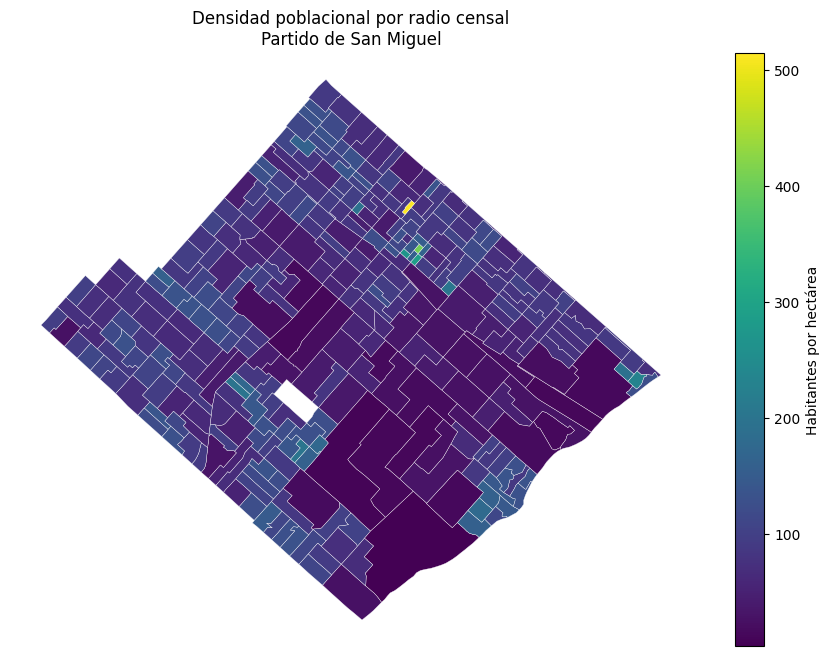

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 11))

san_miguel_completo.plot(
    ax=ax,
    column="densHabHa",
    legend=True,
    edgecolor="white",
    linewidth=0.25,
    legend_kwds={
        "label": "Habitantes por hectárea",
        "shrink": 0.7
    }
)

ax.set_title(
    "Densidad poblacional por radio censal\nPartido de San Miguel"
)

ax.axis("off")
plt.show()

In [17]:
poblacion_barrios = (
    san_miguel_completo
    .groupby("barrio_nombre", as_index=False)
    .agg(
        poblacion=("poblacion", "sum"),
        radios=("CRO", "count")
    )
    .sort_values("poblacion", ascending=False)
)

poblacion_barrios.head(10)

,barrio_nombre,poblacion,radios
31,San Miguel Norte,30082.0,44
2,Bella Vista Norte,22926.0,27
3,Bella Vista Oeste,21722.0,22
22,Obligado,19299.0,17
20,Muniz Norte,19198.0,26
34,Santa Brigida,19125.0,17
19,Mitre,17429.0,14
37,Sarmiento,13353.0,11
21,Muniz Oeste,12808.0,15
32,San Miguel Oeste,9726.0,13


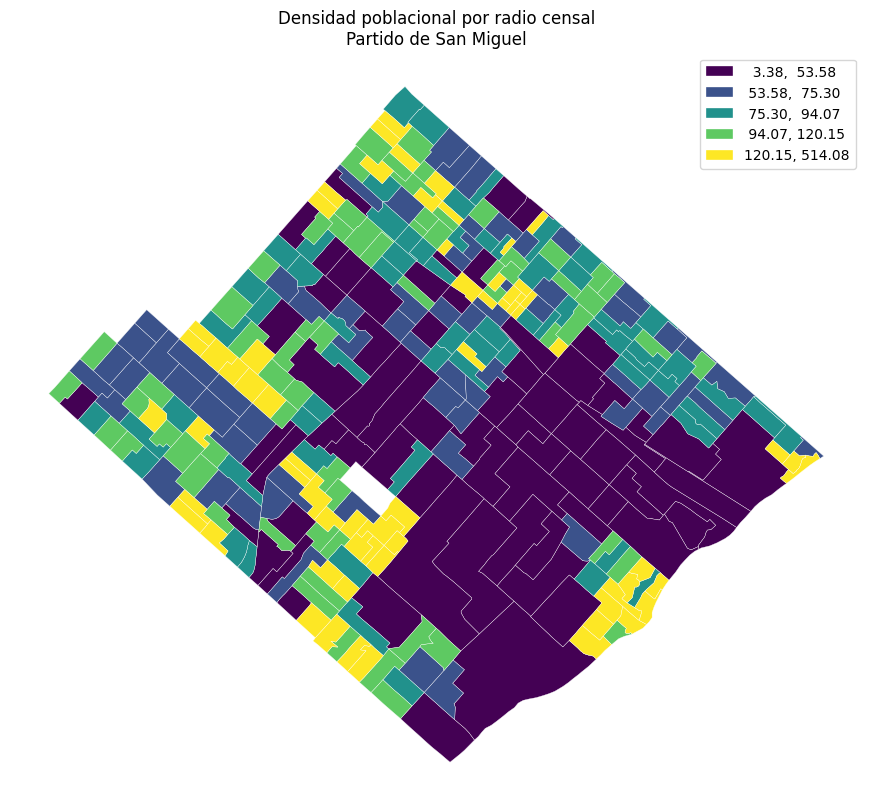

In [18]:
fig, ax = plt.subplots(figsize=(11, 11))

san_miguel_completo.plot(
    ax=ax,
    column="densHabHa",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.25
)

ax.set_title(
    "Densidad poblacional por radio censal\nPartido de San Miguel"
)

ax.axis("off")
plt.show()

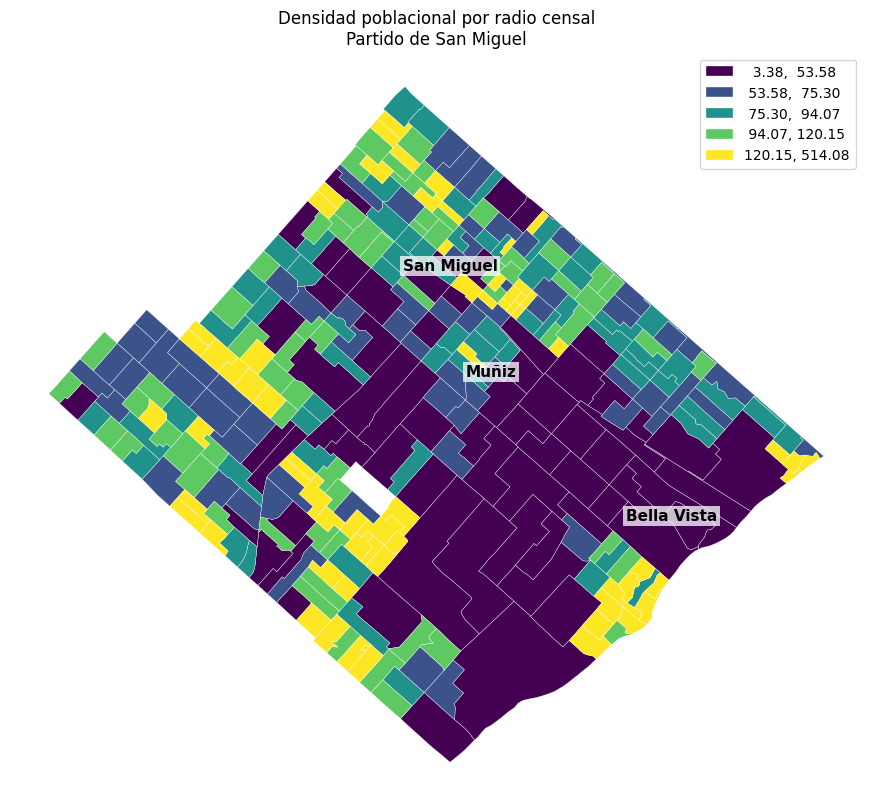

In [19]:
import matplotlib.pyplot as plt

# Crear una categoría simplificada para las localidades principales
def localidad_principal(nombre):
    nombre = str(nombre).lower()

    if "bella vista" in nombre:
        return "Bella Vista"
    elif "muniz" in nombre or "muñiz" in nombre:
        return "Muñiz"
    elif "san miguel" in nombre:
        return "San Miguel"
    else:
        return None

san_miguel_completo["localidad_principal"] = (
    san_miguel_completo["barrio_nombre"]
    .apply(localidad_principal)
)

# Crear geometría conjunta para cada localidad
localidades = (
    san_miguel_completo[
        san_miguel_completo["localidad_principal"].notna()
    ]
    .dissolve(by="localidad_principal")
)

# Punto representativo para colocar cada nombre
localidades["label_point"] = localidades.geometry.representative_point()

# Mapa
fig, ax = plt.subplots(figsize=(11, 11))

san_miguel_completo.plot(
    ax=ax,
    column="densHabHa",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.25
)

# Agregar nombres
for nombre, fila in localidades.iterrows():
    punto = fila["label_point"]

    ax.text(
        punto.x,
        punto.y,
        nombre,
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            alpha=0.75,
            edgecolor="none",
            pad=2
        )
    )

ax.set_title(
    "Densidad poblacional por radio censal\nPartido de San Miguel"
)

ax.axis("off")
plt.show()

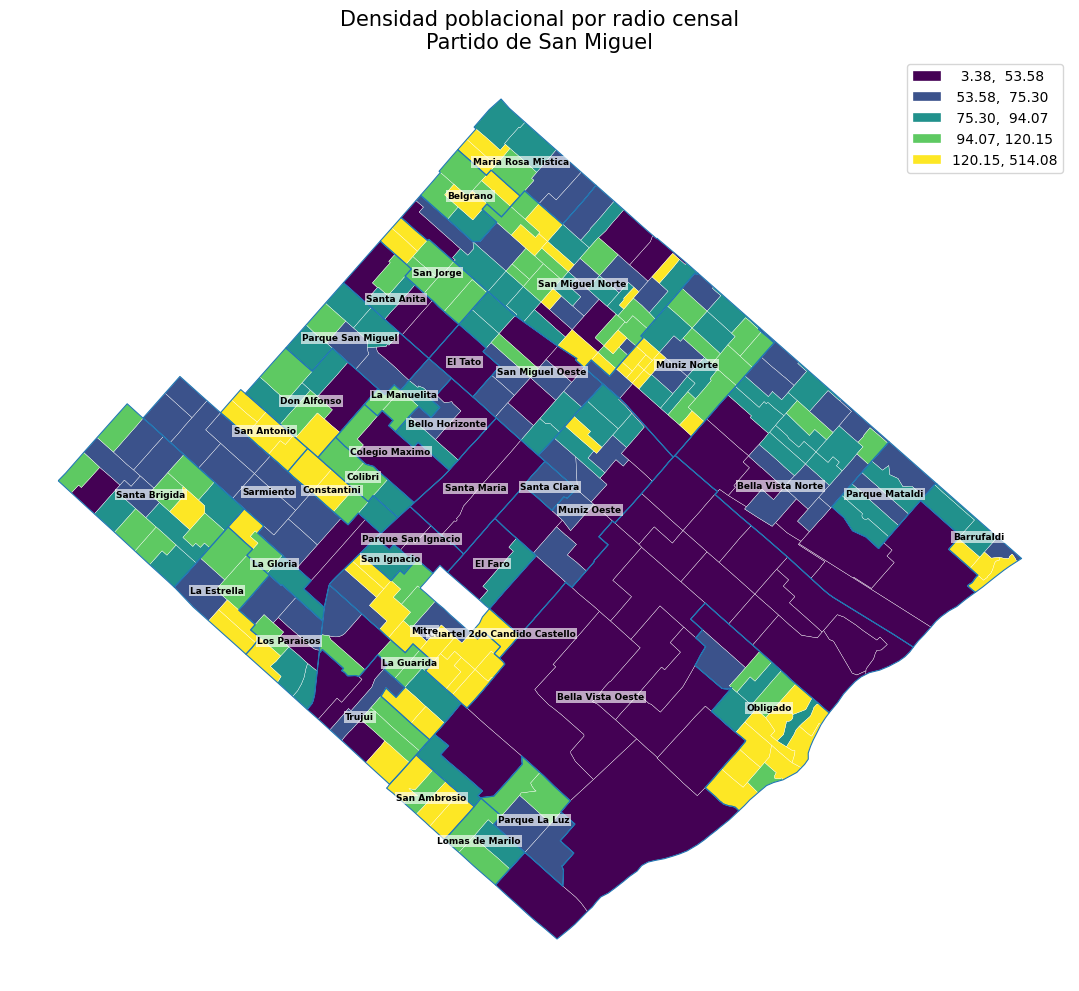

In [20]:
import matplotlib.pyplot as plt

# Unir todos los radios pertenecientes al mismo barrio
barrios_mapa = san_miguel_completo.dissolve(
    by="barrio_nombre"
)

# Punto representativo dentro de cada barrio
barrios_mapa["label_point"] = (
    barrios_mapa.geometry.representative_point()
)

# Crear mapa
fig, ax = plt.subplots(figsize=(14, 12))

san_miguel_completo.plot(
    ax=ax,
    column="densHabHa",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.25
)

# Dibujar límites de barrios
barrios_mapa.boundary.plot(
    ax=ax,
    linewidth=0.8
)

# Agregar nombres
for nombre, fila in barrios_mapa.iterrows():

    punto = fila["label_point"]

    ax.text(
        punto.x,
        punto.y,
        nombre,
        fontsize=6.5,
        ha="center",
        va="center",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            alpha=0.65,
            edgecolor="none",
            pad=1
        )
    )

ax.set_title(
    "Densidad poblacional por radio censal\nPartido de San Miguel",
    fontsize=15
)

ax.axis("off")

plt.show()

In [21]:
san_miguel_completo[
    ["CRO", "barrio_nombre", "poblacion", "densHabHa", "areaHa"]
].sort_values(
    "areaHa",
    ascending=False
).head(20)

,CRO,barrio_nombre,poblacion,densHabHa,areaHa
253,067602909,Bella Vista Oeste,686.0,3.38,202.81
216,067601211,Bella Vista Oeste,1271.0,8.04,158.11
6,067601210,Bella Vista Oeste,1311.0,11.93,109.91
114,067600607,Bella Vista Norte,1490.0,15.04,99.09
286,067602306,Bella Vista Oeste,1238.0,19.33,64.05
26,067602708,Santa Maria,681.0,11.44,59.52
117,067601207,Bella Vista Oeste,1071.0,18.37,58.31
257,067603101,Bella Vista Oeste,1065.0,18.67,57.03
285,067602901,Bella Vista Oeste,1605.0,30.14,53.25
57,067602907,Bella Vista Oeste,739.0,13.99,52.81


In [22]:
sorted(
    san_miguel_completo["barrio_nombre"]
    .dropna()
    .unique()
)

['Barrufaldi',
 'Belgrano',
 'Bella Vista Norte',
 'Bella Vista Oeste',
 'Bello Horizonte',
 'Colegio Maximo',
 'Colibri',
 'Constantini',
 'Cuartel 2do Candido Castello',
 'Don Alfonso',
 'El Faro',
 'El Tato',
 'La Estrella',
 'La Gloria',
 'La Guarida',
 'La Manuelita',
 'Lomas de Marilo',
 'Los Paraisos',
 'Maria Rosa Mistica',
 'Mitre',
 'Muniz Norte',
 'Muniz Oeste',
 'Obligado',
 'Parque La Luz',
 'Parque Mataldi',
 'Parque San Ignacio',
 'Parque San Miguel',
 'San Ambrosio',
 'San Antonio',
 'San Ignacio',
 'San Jorge',
 'San Miguel Norte',
 'San Miguel Oeste',
 'Santa Anita',
 'Santa Brigida',
 'Santa Clara',
 'Santa Maria',
 'Sarmiento',
 'Trujui']

## 2. Red municipal de salud

Consulta y clasificación de los establecimientos del Geoportal de la Municipalidad de San Miguel.


In [23]:
import geopandas as gpd

url_salud = (
    "https://mapas.msm.gov.ar/arcgis/rest/services/"
    "geos_paquetes/salud_entidades/FeatureServer/1/query"
    "?where=1%3D1"
    "&outFields=*"
    "&outSR=4326"
    "&f=geojson"
)

salud_geoportal = gpd.read_file(url_salud)

print(salud_geoportal.shape)
print(salud_geoportal.columns)
salud_geoportal.head()

(46, 18)
Index(['objectid', 'tipo', 'existencia', 'categoria', 'codigo', 'nombre',
       'sobrenombre', 'dir_codigo', 'dir_calle', 'dir_altura', 'nomen',
       'telefono', 'prestaciones', 'horarios', 'etiqueta', 'usuario_id',
       'globalid', 'geometry'],
      dtype='object')


,objectid,tipo,existencia,categoria,codigo,nombre,sobrenombre,dir_codigo,dir_calle,dir_altura,nomen,telefono,prestaciones,horarios,etiqueta,usuario_id,globalid,geometry
0,6,4,1,0,,Base SAME - Indios,,4091,Pardo y Uriarte,0,02 0000 0000 0000 0000 0318 D0000,107,"Emergencias, Traslados",24 Hs.,SAME - Indios,None,{B84B5AB5-EC85-4670-BF79-786955A1EAFF},POINT (-58.72855 -34.58424)
1,7,4,1,0,,Base SAME - Vicentinos,,4173,Av. Primera Junta y Platon,0,02 0000 0000 0000 0000 0021 0000,107,"Emergencias, Traslados",24 Hs.,SAME - Vicentinos,None,{9E944839-4A87-46E0-9A55-84B1E2F881BC},POINT (-58.74028 -34.54961)
2,11,4,1,0,,Base SAME - Larcade,,4166,Av. Pte. J. D. Peron e Ite. J. Irigoin,2311,01 G0000 0000 0000 0047 0009 A0000,107,"Emergencias, Traslados",24 Hs.,SAME - Larcade,None,{4DE42C5D-2E08-43CF-AF9D-398E9F32199E},POINT (-58.72145 -34.53589)
3,12,4,1,0,,Base SAME - San Miguel Arcangel,,8304,Av. Mataldi,1057,01 E0000 0000 0000 0146 0000 0000,107,"Emergencias, Traslados",24 Hs.,SAME - San Miguel Arcangel,None,{6763A2CE-41E8-4353-85EF-D63DDF6804DE},POINT (-58.67894 -34.56198)
4,15,2,0,0,24,Centro de Salud 29 de Septiembre,,4187,Letonia,4746,02 K0000 0000 0000 0006 0025 0000,4455-1135,"Pediatria, Clinica, Ginecologia, Obstetricia, ...",8:00 a 16:00 Hs,CS 29 de Septiembre,None,{C7913794-2FBE-4D73-976B-D7031984818D},POINT (-58.75848 -34.55802)


In [24]:
salud_geoportal["longitud"] = salud_geoportal.geometry.x
salud_geoportal["latitud"] = salud_geoportal.geometry.y

salud_geoportal[
    ["nombre", "latitud", "longitud"]
].head(30)

,nombre,latitud,longitud
0,Base SAME - Indios,-34.584243,-58.728546
1,Base SAME - Vicentinos,-34.549605,-58.740279
2,Base SAME - Larcade,-34.535893,-58.721453
3,Base SAME - San Miguel Arcangel,-34.561984,-58.678941
4,Centro de Salud 29 de Septiembre,-34.558023,-58.758480
5,Hospital Oftalmologico Municipal Mons. Barbich,-34.569112,-58.743033
6,Hospital Oftalmologico y Odontologico Central ...,-34.551364,-58.699832
7,Hospital San Miguel Arcangel,-34.561960,-58.678582
8,Direccion del 1º Nivel de Atencion,-34.543924,-58.712454
9,Centro de Salud Padre Mora (ex La Casita),-34.524541,-58.715793


In [25]:
salud_geoportal.columns.tolist()

['objectid',
 'tipo',
 'existencia',
 'categoria',
 'codigo',
 'nombre',
 'sobrenombre',
 'dir_codigo',
 'dir_calle',
 'dir_altura',
 'nomen',
 'telefono',
 'prestaciones',
 'horarios',
 'etiqueta',
 'usuario_id',
 'globalid',
 'geometry',
 'longitud',
 'latitud']

In [26]:
columnas_interes = [
    "codigo",
    "nombre",
    "tipo",
    "existencia",
    "categoria",
    "dir_calle",
    "dir_altura",
    "prestaciones",
    "horarios",
    "latitud",
    "longitud"
]

salud_geoportal[columnas_interes]

,codigo,nombre,tipo,existencia,categoria,dir_calle,dir_altura,prestaciones,horarios,latitud,longitud
0,,Base SAME - Indios,4,1,0,Pardo y Uriarte,0,"Emergencias, Traslados",24 Hs.,-34.584243,-58.728546
1,,Base SAME - Vicentinos,4,1,0,Av. Primera Junta y Platon,0,"Emergencias, Traslados",24 Hs.,-34.549605,-58.740279
2,,Base SAME - Larcade,4,1,0,Av. Pte. J. D. Peron e Ite. J. Irigoin,2311,"Emergencias, Traslados",24 Hs.,-34.535893,-58.721453
3,,Base SAME - San Miguel Arcangel,4,1,0,Av. Mataldi,1057,"Emergencias, Traslados",24 Hs.,-34.561984,-58.678941
4,24,Centro de Salud 29 de Septiembre,2,0,0,Letonia,4746,"Pediatria, Clinica, Ginecologia, Obstetricia, ...",8:00 a 16:00 Hs,-34.558023,-58.758480
5,19,Hospital Oftalmologico Municipal Mons. Barbich,3,1,0,Av. R. Balbin,4774,,8:00 a 16:00 Hs,-34.569112,-58.743033
6,27,Hospital Oftalmologico y Odontologico Central ...,3,1,0,Av. Pres. J. D. Peron y J. B. Alberdi,0,,8:00 a 16:00 Hs,-34.551364,-58.699832
7,10,Hospital San Miguel Arcangel,1,1,0,Av. Mataldi,1057,,8:00 a 20:00 Hs / Guardia 24 Hs,-34.561960,-58.678582
8,15,Direccion del 1º Nivel de Atencion,2,1,0,Belgrano,1342,,8:00 a 18:00 Hs,-34.543924,-58.712454
9,23,Centro de Salud Padre Mora (ex La Casita),2,0,0,J. M. Rosa,2723,"Pediatria, Clinica, Ginecologia, Obstetricia, ...",8:00 a 16:00 Hs,-34.524541,-58.715793


In [27]:
excluir = [
    "Direccion del 1º Nivel de Atencion",
    "Secretaria de Salud"
]

salud_asistencial = salud_geoportal[
    (salud_geoportal["existencia"] == 1) &
    (salud_geoportal["tipo"].isin([1, 2, 3])) &
    (~salud_geoportal["nombre"].isin(excluir))
].copy()

In [28]:
# Excluimos dependencias administrativas
excluir = [
    "Direccion del 1º Nivel de Atencion",
    "Secretaria de Salud"
]

salud_actual = salud_geoportal[
    (salud_geoportal["existencia"] == 1) &
    (salud_geoportal["tipo"].isin([1, 2, 3])) &
    (~salud_geoportal["nombre"].isin(excluir))
].copy()

print("Establecimientos incluidos:", len(salud_actual))

salud_actual[
    ["codigo", "nombre", "tipo", "latitud", "longitud"]
].sort_values(["tipo", "nombre"])

Establecimientos incluidos: 28


,codigo,nombre,tipo,latitud,longitud
10,08,Hospital Raul Larcade,1,-34.536172,-58.721350
7,10,Hospital San Miguel Arcangel,1,-34.561960,-58.678582
11,0,Hospital Santa Maria,1,-34.563760,-58.737937
20,20,Centro Integrador Comunitario (C.I.C.) Maria L...,2,-34.573506,-58.729495
29,28,Centro de Salud 20 de Julio,2,-34.558103,-58.735305
35,24,Centro de Salud 29 de Septiembre,2,-34.559713,-58.765726
21,04,Centro de Salud Ana Teresa Barthalot (ex Bella...,2,-34.552388,-58.687885
28,26,Centro de Salud Camila Rolon,2,-34.545108,-58.703365
24,05,Centro de Salud Candido Castello,2,-34.573694,-58.721493
30,01,Centro de Salud Cura Brochero (ex 17 de Agosto),2,-34.565398,-58.657445


In [29]:
print("CRS radios:", san_miguel_completo.crs)
print("CRS salud:", salud_actual.crs)

CRS radios: EPSG:4326
CRS salud: EPSG:4326


In [30]:
salud_mapa = salud_actual.to_crs(
    san_miguel_completo.crs
)

In [31]:
tipo_nombre = {
    1: "Hospital general",
    2: "Primer nivel",
    3: "Hospital especializado"
}

salud_actual["tipo_salud"] = salud_actual["tipo"].map(tipo_nombre)

print(salud_actual["tipo_salud"].value_counts())

tipo_salud
Primer nivel              20
Hospital especializado     5
Hospital general           3
Name: count, dtype: int64


In [32]:
salud_actual[
    ["nombre", "tipo", "tipo_salud"]
].sort_values(["tipo", "nombre"])

,nombre,tipo,tipo_salud
10,Hospital Raul Larcade,1,Hospital general
7,Hospital San Miguel Arcangel,1,Hospital general
11,Hospital Santa Maria,1,Hospital general
20,Centro Integrador Comunitario (C.I.C.) Maria L...,2,Primer nivel
29,Centro de Salud 20 de Julio,2,Primer nivel
35,Centro de Salud 29 de Septiembre,2,Primer nivel
21,Centro de Salud Ana Teresa Barthalot (ex Bella...,2,Primer nivel
28,Centro de Salud Camila Rolon,2,Primer nivel
24,Centro de Salud Candido Castello,2,Primer nivel
30,Centro de Salud Cura Brochero (ex 17 de Agosto),2,Primer nivel


In [33]:
salud_mapa = salud_actual.copy()

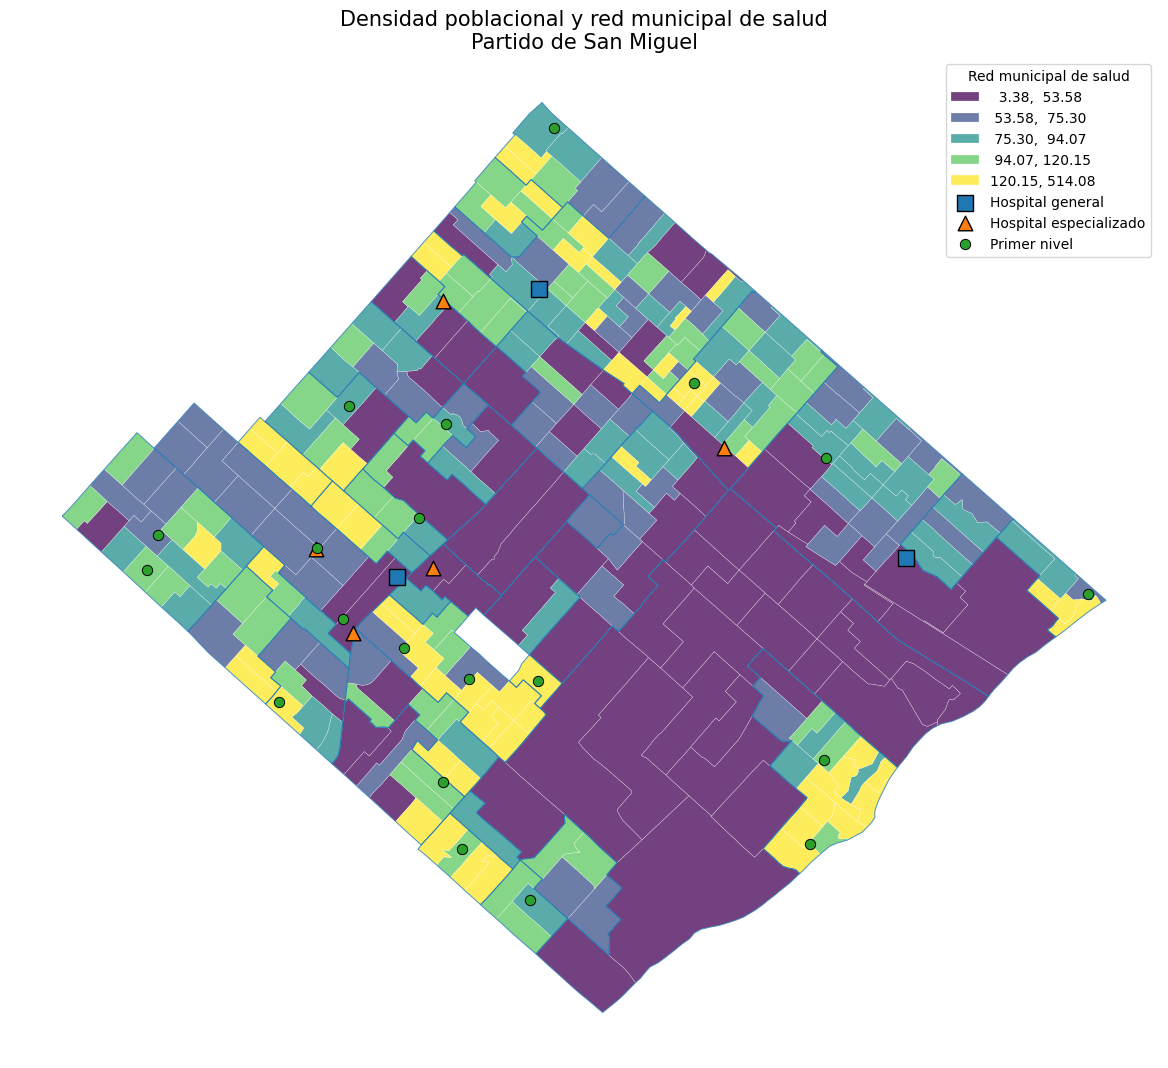

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 13))

# Densidad poblacional
san_miguel_completo.plot(
    ax=ax,
    column="densHabHa",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.25,
    alpha=0.75
)

# Límites de barrios
barrios_mapa.boundary.plot(
    ax=ax,
    linewidth=0.7,
    alpha=0.8
)

# Hospitales generales
salud_mapa[
    salud_mapa["tipo_salud"] == "Hospital general"
].plot(
    ax=ax,
    marker="s",
    markersize=130,
    edgecolor="black",
    linewidth=1,
    label="Hospital general",
    zorder=5
)

# Hospitales especializados
salud_mapa[
    salud_mapa["tipo_salud"] == "Hospital especializado"
].plot(
    ax=ax,
    marker="^",
    markersize=110,
    edgecolor="black",
    linewidth=1,
    label="Hospital especializado",
    zorder=5
)

# Primer nivel
salud_mapa[
    salud_mapa["tipo_salud"] == "Primer nivel"
].plot(
    ax=ax,
    marker="o",
    markersize=55,
    edgecolor="black",
    linewidth=0.7,
    label="Primer nivel",
    zorder=5
)

ax.legend(
    title="Red municipal de salud",
    loc="upper right"
)

ax.set_title(
    "Densidad poblacional y red municipal de salud\n"
    "Partido de San Miguel",
    fontsize=15
)

ax.axis("off")

plt.show()

## 3. Accesibilidad euclídea

Cálculo de proximidad utilizando puntos representativos de los radios censales y coordenadas métricas.


In [35]:
# Proyectar a coordenadas métricas
radios_m = san_miguel_completo.to_crs(epsg=32721)
salud_m = salud_actual.to_crs(epsg=32721)

print(radios_m.crs)
print(salud_m.crs)

EPSG:32721
EPSG:32721


In [36]:
puntos_radios = radios_m.copy()

puntos_radios["geometry"] = puntos_radios.geometry.representative_point()

In [37]:
distancias = gpd.sjoin_nearest(
    puntos_radios,
    salud_m[
        ["nombre", "tipo_salud", "geometry"]
    ],
    how="left",
    distance_col="distancia_m"
)

distancias["distancia_km"] = (
    distancias["distancia_m"] / 1000
)

distancias[
    [
        "CRO",
        "barrio_nombre",
        "poblacion",
        "nombre",
        "tipo_salud",
        "distancia_km"
    ]
].head(10)

,CRO,barrio_nombre,poblacion,nombre,tipo_salud,distancia_km
0,067603004,Trujui,704.0,Centro de Salud Dr. Rene Favaloro (ex Trujui),Primer nivel,0.976291
1,067601106,Parque San Miguel,968.0,Centro de Salud UFO,Primer nivel,0.473404
2,067601901,Maria Rosa Mistica,1397.0,Centro de Salud Padre Mora,Primer nivel,0.794911
3,067600902,San Miguel Norte,737.0,Hospital de Dia Salud Metal,Hospital especializado,0.620409
4,067602510,Santa Anita,843.0,Hospital de Dia Salud Metal,Hospital especializado,0.595541
5,067601905,San Miguel Norte,902.0,Hospital Raul Larcade,Hospital general,0.867927
6,067601210,Bella Vista Oeste,1311.0,Centro de Salud Candido Castello,Primer nivel,1.117009
7,067600303,Muniz Norte,1317.0,Centro de Salud Camila Rolon,Primer nivel,0.427978
8,067600901,San Miguel Norte,883.0,Hospital de Dia Salud Metal,Hospital especializado,0.768850
9,067602106,Muniz Norte,438.0,Centro de Salud Camila Rolon,Primer nivel,0.180884


In [38]:
distancias["distancia_km"].describe()

,distancia_km
count,326.000000
mean,0.618021
std,0.345695
min,0.020283
25%,0.347509
50%,0.568677
75%,0.860404
max,1.729161


In [39]:
primer_nivel = salud_m[
    salud_m["tipo_salud"] == "Primer nivel"
].copy()

dist_primaria = gpd.sjoin_nearest(
    puntos_radios,
    primer_nivel[["nombre", "geometry"]],
    how="left",
    distance_col="distancia_m"
)

dist_primaria["distancia_km"] = (
    dist_primaria["distancia_m"] / 1000
)

dist_primaria["distancia_km"].describe()

,distancia_km
count,326.000000
mean,0.770851
std,0.443585
min,0.020283
25%,0.400756
50%,0.714865
75%,1.103146
max,1.810540


In [40]:
primer_nivel = salud_m[
    salud_m["tipo_salud"] == "Primer nivel"
].copy()

dist_primaria = gpd.sjoin_nearest(
    puntos_radios,
    primer_nivel[["nombre", "geometry"]],
    how="left",
    distance_col="distancia_m"
)

dist_primaria["distancia_km"] = (
    dist_primaria["distancia_m"] / 1000
)

dist_primaria["distancia_km"].describe()

,distancia_km
count,326.000000
mean,0.770851
std,0.443585
min,0.020283
25%,0.400756
50%,0.714865
75%,1.103146
max,1.810540


In [41]:
hospitales = salud_m[
    salud_m["tipo_salud"] == "Hospital general"
].copy()

dist_hospital = gpd.sjoin_nearest(
    puntos_radios,
    hospitales[["nombre", "geometry"]],
    how="left",
    distance_col="distancia_m"
)

dist_hospital["distancia_km"] = (
    dist_hospital["distancia_m"] / 1000
)

dist_hospital["distancia_km"].describe()

,distancia_km
count,326.000000
mean,1.681879
std,0.804601
min,0.221526
25%,1.120541
50%,1.642336
75%,2.171005
max,4.603264


In [42]:
import numpy as np

media_ponderada_primaria = np.average(
    dist_primaria["distancia_km"],
    weights=dist_primaria["poblacion"]
)

media_ponderada_hospital = np.average(
    dist_hospital["distancia_km"],
    weights=dist_hospital["poblacion"]
)

print(
    "Distancia media ponderada a atención primaria:",
    round(media_ponderada_primaria, 3),
    "km"
)

print(
    "Distancia media ponderada a hospital general:",
    round(media_ponderada_hospital, 3),
    "km"
)

Distancia media ponderada a atención primaria: 0.734 km
Distancia media ponderada a hospital general: 1.745 km


In [43]:
umbrales = [0.5, 1.0, 1.5, 2.0]

def cobertura_por_distancia(df, nombre):
    poblacion_total = df["poblacion"].sum()

    print(nombre)
    print("-" * 45)

    for u in umbrales:
        poblacion = df.loc[
            df["distancia_km"] <= u,
            "poblacion"
        ].sum()

        porcentaje = poblacion / poblacion_total * 100

        print(
            f"≤ {u:.1f} km: "
            f"{poblacion:,.0f} habitantes "
            f"({porcentaje:.1f}%)"
        )

cobertura_por_distancia(
    dist_primaria,
    "ATENCIÓN PRIMARIA"
)

print()

cobertura_por_distancia(
    dist_hospital,
    "HOSPITALES GENERALES"
)

ATENCIÓN PRIMARIA
---------------------------------------------
≤ 0.5 km: 120,665 habitantes (37.0%)
≤ 1.0 km: 243,221 habitantes (74.6%)
≤ 1.5 km: 303,676 habitantes (93.1%)
≤ 2.0 km: 326,091 habitantes (100.0%)

HOSPITALES GENERALES
---------------------------------------------
≤ 0.5 km: 17,759 habitantes (5.4%)
≤ 1.0 km: 65,518 habitantes (20.1%)
≤ 1.5 km: 132,297 habitantes (40.6%)
≤ 2.0 km: 210,580 habitantes (64.6%)


In [44]:
# Una fila por CRO con su distancia al hospital general más cercano
dist_hosp_radio = (
    dist_hospital[
        ["CRO", "distancia_km", "nombre"]
    ]
    .drop_duplicates(subset="CRO")
    .rename(columns={
        "nombre": "hospital_mas_cercano"
    })
)

# Incorporarlo a los polígonos
mapa_hospital = san_miguel_completo.merge(
    dist_hosp_radio,
    on="CRO",
    how="left",
    validate="one_to_one"
)

print("Radios:", len(mapa_hospital))
print(
    "Sin distancia:",
    mapa_hospital["distancia_km"].isna().sum()
)

Radios: 326
Sin distancia: 0


In [45]:
import pandas as pd

mapa_hospital["rango_distancia"] = pd.cut(
    mapa_hospital["distancia_km"],
    bins=[0, 0.5, 1.0, 1.5, 2.0, float("inf")],
    labels=[
        "≤ 0,5 km",
        "0,5–1 km",
        "1–1,5 km",
        "1,5–2 km",
        "> 2 km"
    ],
    include_lowest=True
)

mapa_hospital["rango_distancia"].value_counts().sort_index()

,count
rango_distancia,
"≤ 0,5 km",20
"0,5–1 km",52
"1–1,5 km",68
"1,5–2 km",79
> 2 km,107


In [46]:
import pandas as pd

mapa_hospital["rango_distancia"] = pd.cut(
    mapa_hospital["distancia_km"],
    bins=[0, 0.5, 1.0, 1.5, 2.0, float("inf")],
    labels=[
        "≤ 0,5 km",
        "0,5–1 km",
        "1–1,5 km",
        "1,5–2 km",
        "> 2 km"
    ],
    include_lowest=True
)

mapa_hospital["rango_distancia"].value_counts().sort_index()

,count
rango_distancia,
"≤ 0,5 km",20
"0,5–1 km",52
"1–1,5 km",68
"1,5–2 km",79
> 2 km,107


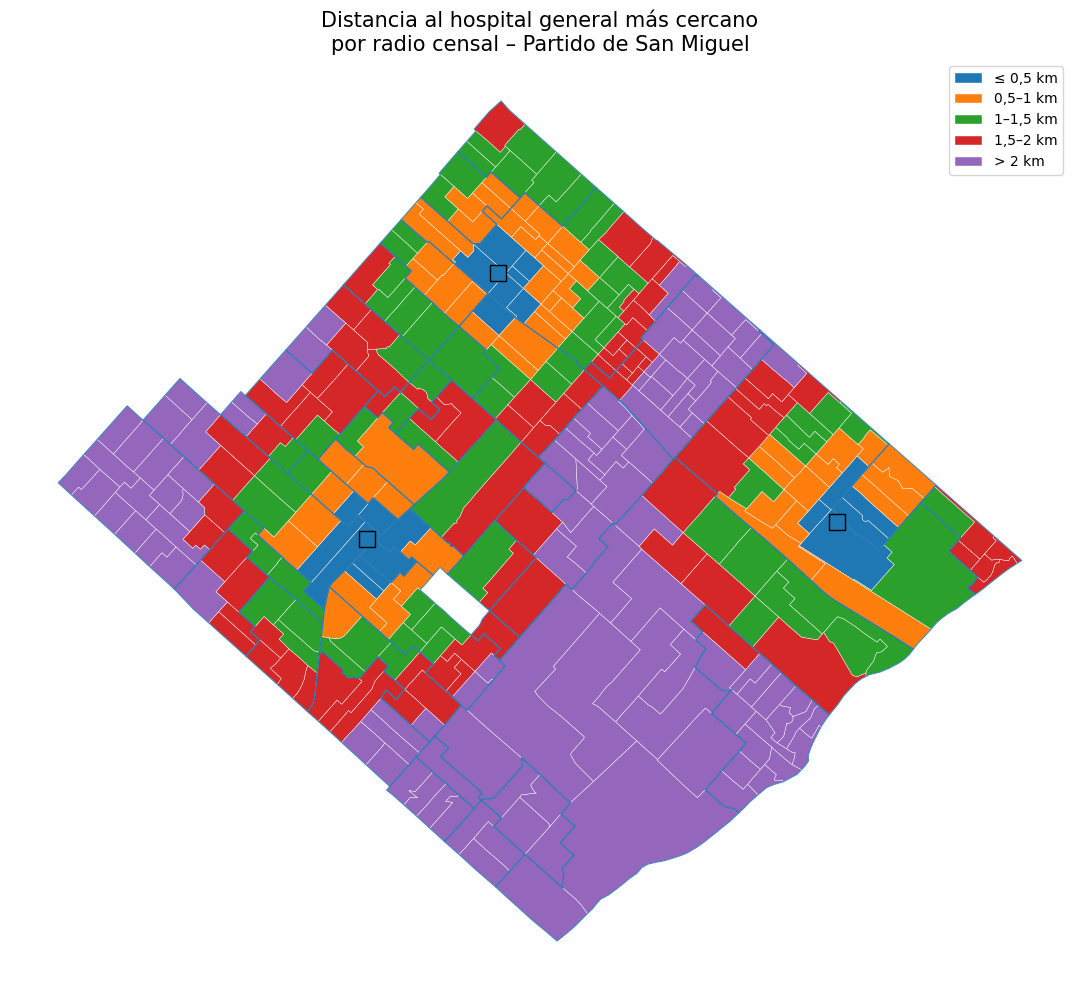

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 12))

mapa_hospital.plot(
    ax=ax,
    column="rango_distancia",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.3
)

# Límites de barrios
barrios_mapa.boundary.plot(
    ax=ax,
    linewidth=0.8,
    alpha=0.8
)

# Solo hospitales generales
hospitales_mapa = salud_actual[
    salud_actual["tipo_salud"] == "Hospital general"
].copy()

hospitales_mapa.plot(
    ax=ax,
    marker="s",
    markersize=120,
    edgecolor="black",
    linewidth=1,
    label="Hospital general",
    zorder=5
)

ax.set_title(
    "Distancia al hospital general más cercano\n"
    "por radio censal – Partido de San Miguel",
    fontsize=15
)

ax.axis("off")

plt.show()

In [48]:
# Hospitales generales
hospitales_mapa = salud_actual[
    salud_actual["tipo_salud"] == "Hospital general"
].copy()

for _, fila in hospitales_mapa.iterrows():
    ax.annotate(
        fila["nombre"].replace("Hospital ", ""),
        xy=(fila.geometry.x, fila.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            alpha=0.8,
            edgecolor="none",
            pad=1
        ),
        zorder=6
    )

In [49]:
mas_2km = mapa_hospital[
    mapa_hospital["distancia_km"] > 2
].copy()

barrios_mas_2km = (
    mas_2km
    .groupby("barrio_nombre")
    .agg(
        poblacion_mas_2km=("poblacion", "sum"),
        radios_mas_2km=("CRO", "count"),
        distancia_media=("distancia_km", "mean"),
        distancia_maxima=("distancia_km", "max")
    )
    .sort_values(
        "poblacion_mas_2km",
        ascending=False
    )
)

barrios_mas_2km.head(15)

,poblacion_mas_2km,radios_mas_2km,distancia_media,distancia_maxima
barrio_nombre,,,,
Obligado,18671.0,16,2.534286,3.349679
Santa Brigida,16773.0,15,2.674355,3.398252
Muniz Norte,16261.0,20,2.270243,2.641898
Bella Vista Oeste,12539.0,12,2.945639,4.603264
Muniz Oeste,10169.0,13,2.343054,2.640352
Parque La Luz,8118.0,5,3.552627,4.159959
San Ambrosio,5976.0,4,3.097726,3.369352
Trujui,5131.0,4,2.366331,2.612030
Lomas de Marilo,4579.0,3,3.813501,4.001188


In [50]:
# Población total por barrio
pob_total_barrio = (
    mapa_hospital
    .groupby("barrio_nombre")["poblacion"]
    .sum()
    .rename("poblacion_total")
)

# Unir con población >2 km
barrios_mas_2km = barrios_mas_2km.join(
    pob_total_barrio
)

# Porcentaje
barrios_mas_2km["porcentaje_mas_2km"] = (
    barrios_mas_2km["poblacion_mas_2km"]
    / barrios_mas_2km["poblacion_total"]
    * 100
)

barrios_mas_2km[
    [
        "poblacion_total",
        "poblacion_mas_2km",
        "porcentaje_mas_2km",
        "distancia_media",
        "distancia_maxima"
    ]
].sort_values(
    "porcentaje_mas_2km",
    ascending=False
).head(15)

,poblacion_total,poblacion_mas_2km,porcentaje_mas_2km,distancia_media,distancia_maxima
barrio_nombre,,,,,
Lomas de Marilo,4579.0,4579.0,100.000000,3.813501,4.001188
Parque La Luz,8118.0,8118.0,100.000000,3.552627,4.159959
San Ambrosio,5976.0,5976.0,100.000000,3.097726,3.369352
Santa Clara,916.0,916.0,100.000000,2.187142,2.187142
Obligado,19299.0,18671.0,96.745945,2.534286,3.349679
Santa Brigida,19125.0,16773.0,87.701961,2.674355,3.398252
Muniz Norte,19198.0,16261.0,84.701531,2.270243,2.641898
Muniz Oeste,12808.0,10169.0,79.395690,2.343054,2.640352
Trujui,7907.0,5131.0,64.891868,2.366331,2.612030


In [51]:
dist_primaria_radio = (
    dist_primaria[
        ["CRO", "distancia_km", "nombre"]
    ]
    .drop_duplicates(subset="CRO")
    .rename(columns={
        "nombre": "centro_mas_cercano"
    })
)

mapa_primaria = san_miguel_completo.merge(
    dist_primaria_radio,
    on="CRO",
    how="left",
    validate="one_to_one"
)

print("Radios:", len(mapa_primaria))
print(
    "Sin distancia:",
    mapa_primaria["distancia_km"].isna().sum()
)

Radios: 326
Sin distancia: 0


In [52]:
mapa_primaria["rango_distancia"] = pd.cut(
    mapa_primaria["distancia_km"],
    bins=[0, 0.5, 1.0, 1.5, 2.0, float("inf")],
    labels=[
        "≤ 0,5 km",
        "0,5–1 km",
        "1–1,5 km",
        "1,5–2 km",
        "2 km"
    ],
    include_lowest=True
)

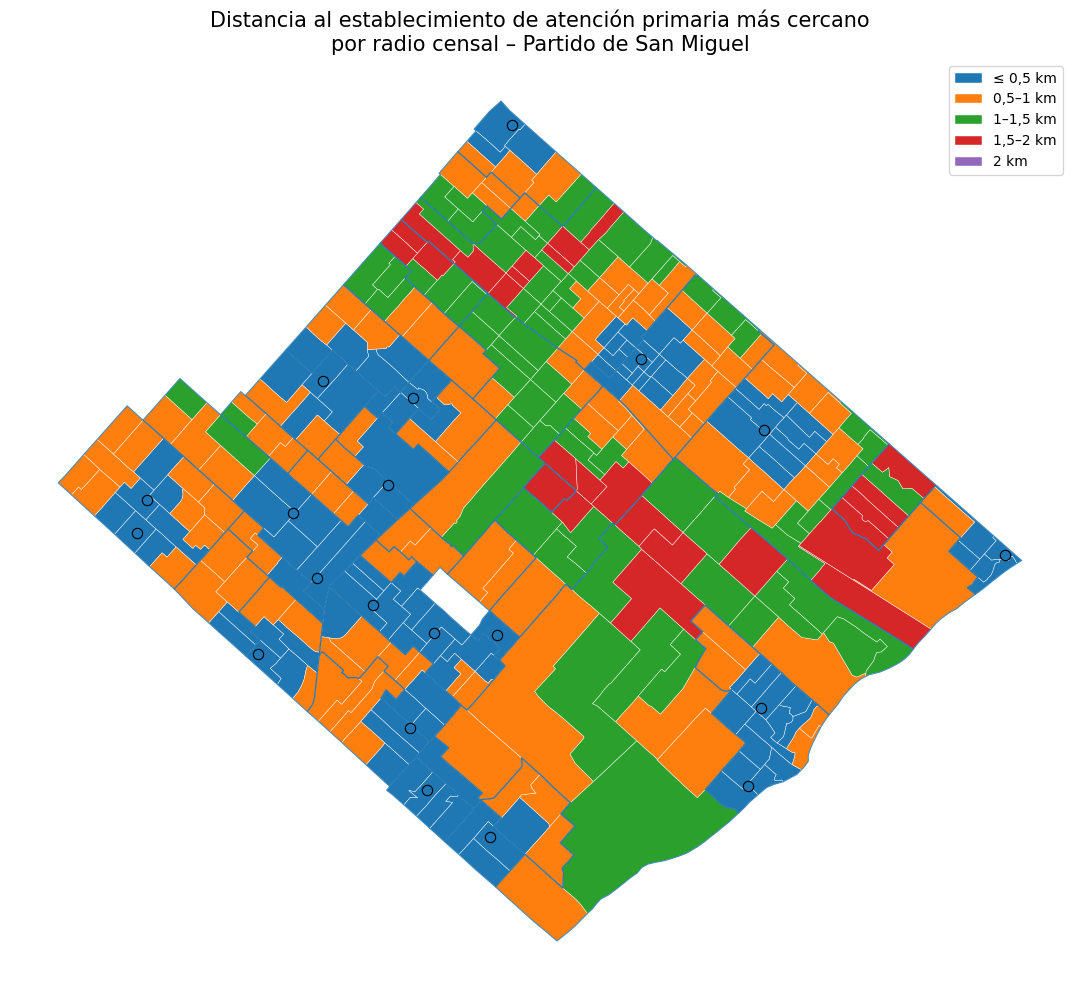

In [53]:
fig, ax = plt.subplots(figsize=(14, 12))

mapa_primaria.plot(
    ax=ax,
    column="rango_distancia",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.3
)

# Límites de barrios
barrios_mapa.boundary.plot(
    ax=ax,
    linewidth=0.8,
    alpha=0.8
)

# Establecimientos de primer nivel
primer_nivel_mapa = salud_actual[
    salud_actual["tipo_salud"] == "Primer nivel"
].copy()

primer_nivel_mapa.plot(
    ax=ax,
    marker="o",
    markersize=55,
    edgecolor="black",
    linewidth=0.8,
    label="Primer nivel",
    zorder=5
)

ax.set_title(
    "Distancia al establecimiento de atención primaria más cercano\n"
    "por radio censal – Partido de San Miguel",
    fontsize=15
)

ax.axis("off")

plt.show()

In [54]:
mas_15km_primaria = mapa_primaria[
    mapa_primaria["distancia_km"] > 1.5
].copy()

barrios_mas_15km_primaria = (
    mas_15km_primaria
    .groupby("barrio_nombre")
    .agg(
        poblacion_mas_15km=("poblacion", "sum"),
        radios_mas_15km=("CRO", "count"),
        distancia_media=("distancia_km", "mean"),
        distancia_maxima=("distancia_km", "max")
    )
)

# Población total de cada barrio
pob_total_barrio = (
    mapa_primaria
    .groupby("barrio_nombre")["poblacion"]
    .sum()
    .rename("poblacion_total")
)

barrios_mas_15km_primaria = (
    barrios_mas_15km_primaria
    .join(pob_total_barrio)
)

barrios_mas_15km_primaria["porcentaje_mas_15km"] = (
    barrios_mas_15km_primaria["poblacion_mas_15km"]
    / barrios_mas_15km_primaria["poblacion_total"]
    * 100
)

barrios_mas_15km_primaria[
    [
        "poblacion_total",
        "poblacion_mas_15km",
        "porcentaje_mas_15km",
        "radios_mas_15km",
        "distancia_media",
        "distancia_maxima"
    ]
].sort_values(
    "poblacion_mas_15km",
    ascending=False
)

,poblacion_total,poblacion_mas_15km,porcentaje_mas_15km,radios_mas_15km,distancia_media,distancia_maxima
barrio_nombre,,,,,,
San Miguel Norte,30082.0,5922.0,19.686191,8,1.604908,1.715612
Parque Mataldi,5508.0,4188.0,76.034858,4,1.547362,1.574832
Bella Vista Oeste,21722.0,3963.0,18.244176,4,1.691404,1.776049
Muniz Oeste,12808.0,3015.0,23.539975,4,1.569555,1.684898
San Jorge,6597.0,2882.0,43.686524,3,1.685293,1.746753
Bella Vista Norte,22926.0,1529.0,6.669284,2,1.650518,1.678017
Santa Clara,916.0,916.0,100.000000,1,1.810540,1.810540


## 4. Accesibilidad por red vial

Construcción de la red vial de OpenStreetMap y cálculo de caminos mínimos mediante OSMnx/NetworkX.


In [ ]:
!pip install osmnx


In [57]:
import osmnx as ox
import geopandas as gpd
import networkx as nx
import numpy as np
import pandas as pd

ox.settings.use_cache = True
ox.settings.log_console = True

# Crear área ampliada alrededor de San Miguel
limite = (
    san_miguel_completo
    .to_crs(32721)
    .geometry
    .union_all()
)

area_red = limite.buffer(5000)

area_red_gdf = gpd.GeoDataFrame(
    geometry=[area_red],
    crs=32721
).to_crs(4326)

area_red_wgs84 = area_red_gdf.geometry.iloc[0]

# Descargar red vial apta para automóviles
G = ox.graph_from_polygon(
    area_red_wgs84,
    network_type="drive",
    simplify=True
)

# Agregar velocidades y tiempos estimados
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

print(G)

MultiDiGraph with 21157 nodes and 66313 edges


In [59]:
radios_wgs = san_miguel_completo.to_crs(4326).copy()
radios_wgs["geometry"] = radios_wgs.geometry.representative_point()

hospitales_wgs = salud_actual[
    salud_actual["tipo_salud"] == "Hospital general"
].to_crs(4326).copy()

print(len(radios_wgs))
print(len(hospitales_wgs))
print(hospitales_wgs["nombre"].tolist())

326
3
['Hospital San Miguel Arcangel', 'Hospital Raul Larcade', 'Hospital Santa Maria']


In [60]:
radios_wgs["nodo_red"] = ox.distance.nearest_nodes(
    G,
    X=radios_wgs.geometry.x,
    Y=radios_wgs.geometry.y
)

hospitales_wgs["nodo_red"] = ox.distance.nearest_nodes(
    G,
    X=hospitales_wgs.geometry.x,
    Y=hospitales_wgs.geometry.y
)

In [61]:
print(radios_wgs[["CRO", "barrio_nombre", "nodo_red"]].head())

print(
    hospitales_wgs[
        ["nombre", "nodo_red"]
    ]
)

         CRO       barrio_nombre    nodo_red
0  067603004              Trujui   715043314
1  067601106   Parque San Miguel  1862240642
2  067601901  Maria Rosa Mistica   292552622
3  067600902    San Miguel Norte  3049154409
4  067602510         Santa Anita   297391248
                          nombre   nodo_red
7   Hospital San Miguel Arcangel  298934370
10         Hospital Raul Larcade  292546101
11          Hospital Santa Maria  334300038


In [62]:
resultados = []

for idx, radio in radios_wgs.iterrows():

    origen = radio["nodo_red"]

    mejor_tiempo = np.inf
    mejor_hospital = None

    for _, hospital in hospitales_wgs.iterrows():

        destino = hospital["nodo_red"]

        try:
            tiempo_seg = nx.shortest_path_length(
                G,
                source=origen,
                target=destino,
                weight="travel_time"
            )

            if tiempo_seg < mejor_tiempo:
                mejor_tiempo = tiempo_seg
                mejor_hospital = hospital["nombre"]

        except nx.NetworkXNoPath:
            continue

    resultados.append({
        "CRO": radio["CRO"],
        "barrio_nombre": radio["barrio_nombre"],
        "poblacion": radio["poblacion"],
        "hospital_red_mas_cercano": mejor_hospital,
        "tiempo_auto_min": mejor_tiempo / 60
    })

acceso_vial = pd.DataFrame(resultados)

In [63]:
resultados = []

for idx, radio in radios_wgs.iterrows():

    origen = radio["nodo_red"]

    mejor_tiempo = np.inf
    mejor_hospital = None
    mejor_distancia = None

    for _, hospital in hospitales_wgs.iterrows():

        destino = hospital["nodo_red"]

        try:
            ruta = nx.shortest_path(
                G,
                source=origen,
                target=destino,
                weight="travel_time"
            )

            tiempo_seg = nx.path_weight(
                G,
                ruta,
                weight="travel_time"
            )

            distancia_m = nx.path_weight(
                G,
                ruta,
                weight="length"
            )

            if tiempo_seg < mejor_tiempo:
                mejor_tiempo = tiempo_seg
                mejor_distancia = distancia_m
                mejor_hospital = hospital["nombre"]

        except nx.NetworkXNoPath:
            continue

    resultados.append({
        "CRO": radio["CRO"],
        "barrio_nombre": radio["barrio_nombre"],
        "poblacion": radio["poblacion"],
        "hospital_red_mas_cercano": mejor_hospital,
        "distancia_vial_km": mejor_distancia / 1000,
        "tiempo_auto_min": mejor_tiempo / 60
    })

acceso_vial = pd.DataFrame(resultados)

In [64]:
acceso_vial[[
    "distancia_vial_km",
    "tiempo_auto_min"
]].describe()

,distancia_vial_km,tiempo_auto_min
count,326.000000,326.000000
mean,2.197353,2.959868
std,1.126104,1.434716
min,0.221701,0.308217
25%,1.470361,1.969241
50%,2.115235,2.849077
75%,2.836328,3.780503
max,10.441234,10.930016


In [65]:
comparacion = acceso_vial.merge(
    dist_hosp_radio[[
        "CRO",
        "distancia_km"
    ]],
    on="CRO",
    how="left",
    validate="one_to_one"
)

comparacion = comparacion.rename(
    columns={"distancia_km": "distancia_euclidea_km"}
)

comparacion["factor_red"] = (
    comparacion["distancia_vial_km"] /
    comparacion["distancia_euclidea_km"]
)

comparacion["exceso_red_pct"] = (
    (comparacion["factor_red"] - 1) * 100
)

In [66]:
comparacion[[
    "distancia_euclidea_km",
    "distancia_vial_km",
    "factor_red",
    "exceso_red_pct"
]].describe()

,distancia_euclidea_km,distancia_vial_km,factor_red,exceso_red_pct
count,326.000000,326.000000,326.000000,326.000000
mean,1.681879,2.197353,1.313944,31.394383
std,0.804601,1.126104,0.187053,18.705250
min,0.221526,0.221701,0.809058,-19.094225
25%,1.120541,1.470361,1.195967,19.596697
50%,1.642336,2.115235,1.296399,29.639912
75%,2.171005,2.836328,1.397555,39.755549
max,4.603264,10.441234,2.513172,151.317221


In [67]:
comparacion[[
    "CRO",
    "barrio_nombre",
    "poblacion",
    "hospital_red_mas_cercano",
    "distancia_euclidea_km",
    "distancia_vial_km",
    "factor_red",
    "tiempo_auto_min"
]].sort_values(
    "factor_red",
    ascending=False
).head(15)

,CRO,barrio_nombre,poblacion,hospital_red_mas_cercano,distancia_euclidea_km,distancia_vial_km,factor_red,tiempo_auto_min
253,067602909,Bella Vista Oeste,686.0,Hospital Santa Maria,4.154603,10.441234,2.513172,10.930016
50,067601602,Sarmiento,904.0,Hospital Santa Maria,0.449098,0.940722,2.094690,0.951024
79,067600905,San Miguel Norte,626.0,Hospital Raul Larcade,0.351681,0.723829,2.058195,0.956772
128,067600909,San Miguel Norte,947.0,Hospital Raul Larcade,0.522042,0.990742,1.897821,1.220912
121,067602706,Constantini,896.0,Hospital Santa Maria,0.281671,0.528361,1.875808,0.615907
259,067600805,San Miguel Oeste,794.0,Hospital Santa Maria,1.544865,2.797070,1.810560,3.163438
78,067602507,San Miguel Oeste,873.0,Hospital Raul Larcade,1.169081,2.112881,1.807301,2.816739
140,067602803,Muniz Oeste,1341.0,Hospital Santa Maria,1.981120,3.464990,1.749006,5.253104
72,067600904,San Miguel Norte,902.0,Hospital Raul Larcade,0.305262,0.525971,1.723016,0.680658
178,067602508,San Miguel Oeste,691.0,Hospital Santa Maria,1.438410,2.472548,1.718946,2.647625


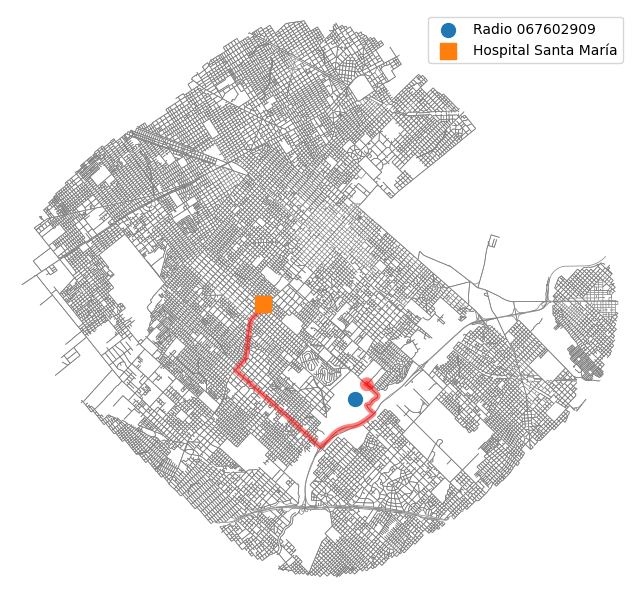

In [68]:
radio_extremo = radios_wgs[
    radios_wgs["CRO"] == "067602909"
].iloc[0]

hospital_sm = hospitales_wgs[
    hospitales_wgs["nombre"] == "Hospital Santa Maria"
].iloc[0]

origen = radio_extremo["nodo_red"]
destino = hospital_sm["nodo_red"]

ruta_extrema = nx.shortest_path(
    G,
    source=origen,
    target=destino,
    weight="travel_time"
)

fig, ax = ox.plot_graph_route(
    G,
    ruta_extrema,
    route_linewidth=4,
    node_size=0,
    bgcolor="white",
    edge_color="gray",
    edge_linewidth=0.5,
    show=False,
    close=False
)

ax.scatter(
    radio_extremo.geometry.x,
    radio_extremo.geometry.y,
    s=100,
    marker="o",
    zorder=5,
    label="Radio 067602909"
)

ax.scatter(
    hospital_sm.geometry.x,
    hospital_sm.geometry.y,
    s=120,
    marker="s",
    zorder=5,
    label="Hospital Santa María"
)

ax.legend()

In [69]:
comparacion_hospitales = []

for _, hospital in hospitales_wgs.iterrows():

    destino = hospital["nodo_red"]

    try:
        ruta = nx.shortest_path(
            G,
            source=origen,
            target=destino,
            weight="travel_time"
        )

        distancia = nx.path_weight(
            G,
            ruta,
            weight="length"
        ) / 1000

        tiempo = nx.path_weight(
            G,
            ruta,
            weight="travel_time"
        ) / 60

        comparacion_hospitales.append({
            "hospital": hospital["nombre"],
            "distancia_vial_km": distancia,
            "tiempo_min": tiempo
        })

    except nx.NetworkXNoPath:
        pass

pd.DataFrame(comparacion_hospitales).sort_values("tiempo_min")

,hospital,distancia_vial_km,tiempo_min
2,Hospital Santa Maria,10.441234,10.930016
0,Hospital San Miguel Arcangel,12.348630,13.082771
1,Hospital Raul Larcade,14.981810,16.330542


In [70]:
resultados_red = []

for _, radio in radios_wgs.iterrows():

    origen = radio["nodo_red"]

    mejor_distancia = np.inf
    mejor_hospital = None
    tiempo_de_esa_ruta = None

    for _, hospital in hospitales_wgs.iterrows():

        destino = hospital["nodo_red"]

        try:
            # La ruta que minimiza DISTANCIA, no tiempo
            ruta = nx.shortest_path(
                G,
                source=origen,
                target=destino,
                weight="length"
            )

            distancia_km = nx.path_weight(
                G, ruta, weight="length"
            ) / 1000

            tiempo_min = nx.path_weight(
                G, ruta, weight="travel_time"
            ) / 60

            if distancia_km < mejor_distancia:
                mejor_distancia = distancia_km
                mejor_hospital = hospital["nombre"]
                tiempo_de_esa_ruta = tiempo_min

        except nx.NetworkXNoPath:
            continue

    resultados_red.append({
        "CRO": radio["CRO"],
        "barrio_nombre": radio["barrio_nombre"],
        "poblacion": radio["poblacion"],
        "hospital_menor_distancia_vial": mejor_hospital,
        "distancia_vial_min_km": mejor_distancia,
        "tiempo_ruta_min_distancia": tiempo_de_esa_ruta
    })

acceso_red = pd.DataFrame(resultados_red)

In [71]:
acceso_red["distancia_vial_min_km"].describe()

,distancia_vial_min_km
count,326.000000
mean,2.149178
std,1.088288
min,0.221701
25%,1.455612
50%,2.058120
75%,2.760730
max,10.369578


In [72]:
acceso_red["distancia_vial_min_km"].describe()

,distancia_vial_min_km
count,326.000000
mean,2.149178
std,1.088288
min,0.221701
25%,1.455612
50%,2.058120
75%,2.760730
max,10.369578


In [73]:
acceso_red.sort_values(
    "distancia_vial_min_km",
    ascending=False
).head(200)

,CRO,barrio_nombre,poblacion,hospital_menor_distancia_vial,distancia_vial_min_km,tiempo_ruta_min_distancia
253,067602909,Bella Vista Oeste,686.0,Hospital Santa Maria,10.369578,11.341757
90,067602911,Bella Vista Oeste,1287.0,Hospital Santa Maria,5.526057,7.354153
291,067603206,Lomas de Marilo,1526.0,Hospital Santa Maria,4.973369,6.525847
65,067603205,Lomas de Marilo,1351.0,Hospital Santa Maria,4.885864,6.582471
295,067602910,Parque La Luz,1565.0,Hospital Santa Maria,4.770421,7.158831
...,...,...,...,...,...,...
324,067600210,San Miguel Norte,337.0,Hospital Raul Larcade,1.823636,2.607208
258,067602806,Mitre,1850.0,Hospital Santa Maria,1.817593,2.727091
120,067602304,Bella Vista Oeste,1323.0,Hospital San Miguel Arcangel,1.815892,2.657823
146,067600511,Bella Vista Norte,1061.0,Hospital San Miguel Arcangel,1.803642,2.706447


In [74]:
acceso_red["hospital_menor_distancia_vial"].value_counts()

,count
hospital_menor_distancia_vial,
Hospital Santa Maria,123
Hospital Raul Larcade,118
Hospital San Miguel Arcangel,85


In [78]:
(
    acceso_red
    .groupby("hospital_menor_distancia_vial")
    .agg(
        radios=("CRO", "count"),
        poblacion=("poblacion", "sum")
    )
    .assign(
        porcentaje_poblacion=lambda x:
            x["poblacion"] / x["poblacion"].sum() * 100
    )
    .sort_values("poblacion", ascending=False)
)

,radios,poblacion,porcentaje_poblacion
hospital_menor_distancia_vial,,,
Hospital Santa Maria,123,148607.0,45.572248
Hospital Raul Larcade,118,96449.0,29.577327
Hospital San Miguel Arcangel,85,81035.0,24.850425


In [79]:
mapa_red = san_miguel_completo.merge(
    acceso_red[
        [
            "CRO",
            "hospital_menor_distancia_vial",
            "distancia_vial_min_km"
        ]
    ],
    on="CRO",
    how="left",
    validate="one_to_one"
)

mapa_red[
    ["CRO", "barrio_nombre", "distancia_vial_min_km"]
].head()

,CRO,barrio_nombre,distancia_vial_min_km
0,067603004,Trujui,2.031071
1,067601106,Parque San Miguel,1.964823
2,067601901,Maria Rosa Mistica,1.565270
3,067600902,San Miguel Norte,1.242539
4,067602510,Santa Anita,1.231569


In [80]:
print("Radios:", len(mapa_red))
print("Sin distancia:", mapa_red["distancia_vial_min_km"].isna().sum())

Radios: 326
Sin distancia: 0


In [81]:
bins = [0, 1, 2, 3, 4, float("inf")]

labels = [
    "≤ 1 km",
    "1–2 km",
    "2–3 km",
    "3–4 km",
    "> 4 km"
]

mapa_red["rango_distancia_vial"] = pd.cut(
    mapa_red["distancia_vial_min_km"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

mapa_red["rango_distancia_vial"].value_counts().sort_index()

,count
rango_distancia_vial,
≤ 1 km,45
1–2 km,108
2–3 km,111
3–4 km,46
> 4 km,16


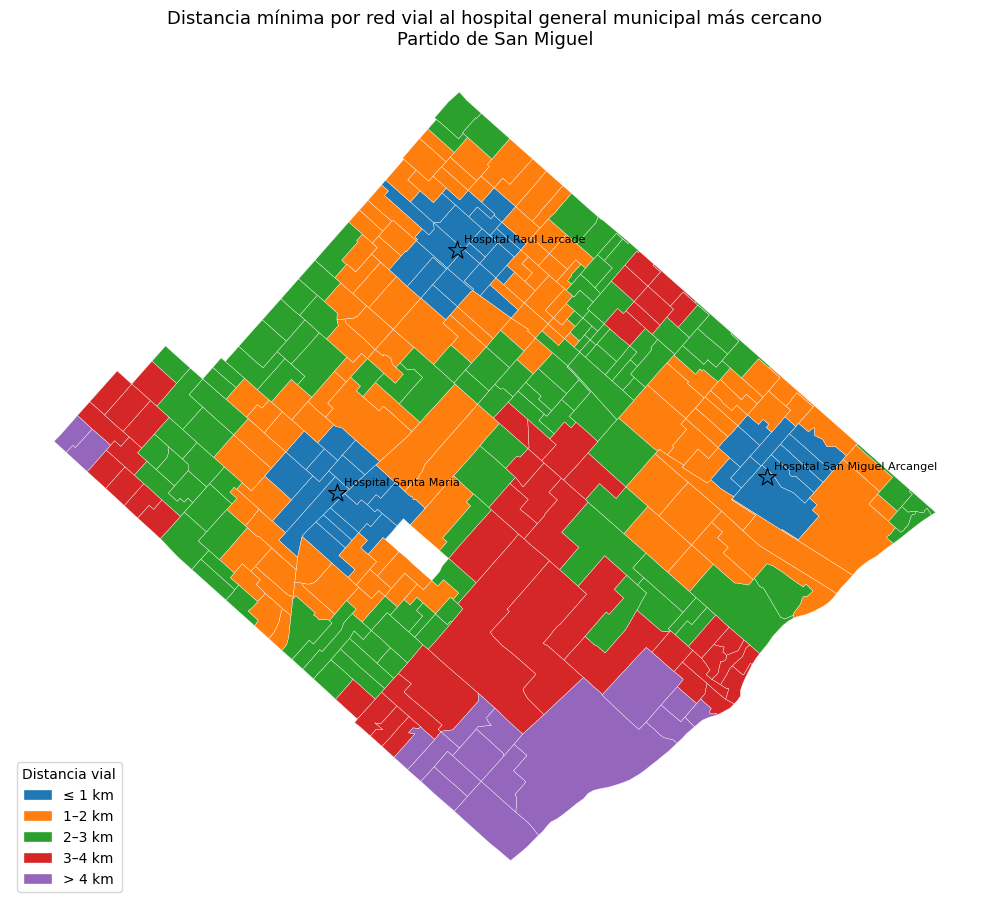

In [82]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

mapa_red.plot(
    column="rango_distancia_vial",
    categorical=True,
    legend=True,
    linewidth=0.25,
    edgecolor="white",
    ax=ax,
    legend_kwds={
        "title": "Distancia vial",
        "loc": "lower left"
    }
)

# Hospitales generales
hospitales_plot = hospitales_wgs.to_crs(mapa_red.crs)

hospitales_plot.plot(
    ax=ax,
    marker="*",
    markersize=180,
    edgecolor="black",
    linewidth=0.8,
    label="Hospital general"
)

# Etiquetas de hospitales
for _, row in hospitales_plot.iterrows():
    ax.annotate(
        row["nombre"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title(
    "Distancia mínima por red vial al hospital general municipal más cercano\n"
    "Partido de San Miguel",
    fontsize=13
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [83]:
# Identificar radios situados a más de 3 km
acceso_red["mas_3km"] = acceso_red["distancia_vial_min_km"] > 3

# Población total por barrio
pob_barrio = (
    acceso_red
    .groupby("barrio_nombre")["poblacion"]
    .sum()
    .rename("poblacion_total")
)

# Radios a más de 3 km
barrios_mas_3km = (
    acceso_red[acceso_red["mas_3km"]]
    .groupby("barrio_nombre")
    .agg(
        poblacion_mas_3km=("poblacion", "sum"),
        radios_mas_3km=("CRO", "count"),
        distancia_media=("distancia_vial_min_km", "mean"),
        distancia_maxima=("distancia_vial_min_km", "max")
    )
)

# Incorporar población total
barrios_mas_3km = barrios_mas_3km.join(pob_barrio)

# Porcentaje de población del barrio
barrios_mas_3km["porcentaje_mas_3km"] = (
    barrios_mas_3km["poblacion_mas_3km"] /
    barrios_mas_3km["poblacion_total"] * 100
)

# Ordenar por cantidad de población afectada
barrios_mas_3km = barrios_mas_3km.sort_values(
    "poblacion_mas_3km",
    ascending=False
)

barrios_mas_3km

,poblacion_mas_3km,radios_mas_3km,distancia_media,distancia_maxima,poblacion_total,porcentaje_mas_3km
barrio_nombre,,,,,,
Obligado,15707.0,13,3.613483,4.504424,19299.0,81.387637
Santa Brigida,11471.0,11,3.666616,4.357862,19125.0,59.979085
Bella Vista Oeste,10785.0,10,4.258871,10.369578,21722.0,49.650124
Parque La Luz,8118.0,5,4.240463,4.770421,8118.0,100.000000
San Ambrosio,5976.0,4,3.828598,4.222495,5976.0,100.000000
Muniz Norte,5949.0,7,3.172375,3.552257,19198.0,30.987603
Muniz Oeste,5806.0,7,3.275327,3.574298,12808.0,45.331043
Lomas de Marilo,4579.0,3,4.735807,4.973369,4579.0,100.000000
Trujui,1553.0,1,3.071206,3.071206,7907.0,19.640825


In [84]:
primer_nivel = salud_actual[
    salud_actual["tipo_salud"] == "Primer nivel"
].copy()

primer_nivel[
    [
        "nombre",
        "prestaciones",
        "horarios",
        "telefono"
    ]
].sort_values("nombre")

,nombre,prestaciones,horarios,telefono
20,Centro Integrador Comunitario (C.I.C.) Maria L...,"Pediatria, Clinica, Ginecologia, Obstetricia, ...",L a V 8 a 17 Hs,Int 4807
29,Centro de Salud 20 de Julio,"Pediatria, Clinica, Ginecologia, Obstetricia, ...","L a V 8 a 15 Hs - M, M y J 8 a 18 Hs",Int 4802
35,Centro de Salud 29 de Septiembre,"L a V 8 a 14 Hs, Sabado 8 a 14 Hs, Martes y Sa...",L a V 8 a 16 Hs,Int 4803
21,Centro de Salud Ana Teresa Barthalot (ex Bella...,"Pediatria, Clinica, Ginecologia, Obstetricia, ...","L a V 8 a 16 Hs, Sabados 8 a 13 Hs",Int 4804
28,Centro de Salud Camila Rolon,"Pediatria, Clinica, Dermatologia, Ginecologia,...",L a V 8 a 16 Hs,Int 4805
24,Centro de Salud Candido Castello,"Pediatria, Clinica, Ginecologia, Obstetricia, ...","L y J 8 a 17 Hs; M, M y V 8 a 16 Hs",4455-7326 (Int 4806)
30,Centro de Salud Cura Brochero (ex 17 de Agosto),"Pediatria, Clinica, Medicina General/Familiar,...",L a V 8 a 17 Hs - L a V 8 a 16 Hs Vacuna,11-3180-3873 (Int 4801)
15,Centro de Salud Dr. Alberto Sabin (ex Los Para...,"Pediatria, Clinica, Obstetricia, Odontologia -...",L a V 8 a 16 Hs,4465-5228 (Int 4809)
23,Centro de Salud Dr. Federico Leloir (Barrio Ob...,"Pediatria, Clinica, Ginecologia, Cardiologia, ...","L a V 8 a 18 Hs, sabados 8 a 13 Hs",4666-4981 (Int 4810)
32,Centro de Salud Dr. Luis Suarez Paris,"Pediatria, Clinica, Ginecologia, Obstetricia, ...",L a V 7 a 16 Hs,Int 4811


In [85]:
print("Centros de primer nivel:", len(primer_nivel))

print("\nPrestaciones con información:")
print(primer_nivel["prestaciones"].notna().sum())

print("\nHorarios con información:")
print(primer_nivel["horarios"].notna().sum())

Centros de primer nivel: 20

Prestaciones con información:
20

Horarios con información:
20


In [86]:
primer_nivel_wgs = salud_actual[
    salud_actual["tipo_salud"] == "Primer nivel"
].to_crs(4326).copy()

primer_nivel_wgs["nodo_red"] = ox.distance.nearest_nodes(
    G,
    X=primer_nivel_wgs.geometry.x,
    Y=primer_nivel_wgs.geometry.y
)

print("Centros de atención primaria:", len(primer_nivel_wgs))

Centros de atención primaria: 20


In [87]:
resultados_primaria_red = []

for _, radio in radios_wgs.iterrows():

    origen = radio["nodo_red"]

    mejor_distancia = np.inf
    mejor_centro = None

    for _, centro in primer_nivel_wgs.iterrows():

        destino = centro["nodo_red"]

        try:
            distancia_m = nx.shortest_path_length(
                G,
                source=origen,
                target=destino,
                weight="length"
            )

            distancia_km = distancia_m / 1000

            if distancia_km < mejor_distancia:
                mejor_distancia = distancia_km
                mejor_centro = centro["nombre"]

        except nx.NetworkXNoPath:
            continue

    resultados_primaria_red.append({
        "CRO": radio["CRO"],
        "barrio_nombre": radio["barrio_nombre"],
        "poblacion": radio["poblacion"],
        "centro_primario_mas_cercano": mejor_centro,
        "distancia_primaria_vial_km": mejor_distancia
    })

acceso_primaria_red = pd.DataFrame(resultados_primaria_red)

In [88]:
print(acceso_primaria_red.shape)

acceso_primaria_red["distancia_primaria_vial_km"].describe()

(326, 5)


,distancia_primaria_vial_km
count,326.000000
mean,1.022335
std,0.643876
min,0.000000
25%,0.541861
50%,0.925686
75%,1.480025
max,6.123596


In [89]:
poblacion_total = acceso_primaria_red["poblacion"].sum()

for umbral in [0.5, 1, 1.5, 2, 2.5, 3]:

    poblacion = acceso_primaria_red.loc[
        acceso_primaria_red["distancia_primaria_vial_km"] > umbral,
        "poblacion"
    ].sum()

    porcentaje = poblacion / poblacion_total * 100

    print(
        f"> {umbral} km: "
        f"{poblacion:,.0f} habitantes "
        f"({porcentaje:.1f}%)"
    )

> 0.5 km: 244,971 habitantes (75.1%)
> 1 km: 129,134 habitantes (39.6%)
> 1.5 km: 67,670 habitantes (20.8%)
> 2 km: 16,634 habitantes (5.1%)
> 2.5 km: 3,163 habitantes (1.0%)
> 3 km: 686 habitantes (0.2%)


In [90]:
# Identificar radios situados a más de 2 km
acceso_primaria_red["mas_2km"] = (
    acceso_primaria_red["distancia_primaria_vial_km"] > 2
)

# Población total por barrio
pob_barrio_primaria = (
    acceso_primaria_red
    .groupby("barrio_nombre")["poblacion"]
    .sum()
    .rename("poblacion_total")
)

# Radios situados a más de 2 km
barrios_primaria_mas_2km = (
    acceso_primaria_red[acceso_primaria_red["mas_2km"]]
    .groupby("barrio_nombre")
    .agg(
        poblacion_mas_2km=("poblacion", "sum"),
        radios_mas_2km=("CRO", "count"),
        distancia_media=("distancia_primaria_vial_km", "mean"),
        distancia_maxima=("distancia_primaria_vial_km", "max")
    )
)

# Incorporar población total del barrio
barrios_primaria_mas_2km = (
    barrios_primaria_mas_2km.join(pob_barrio_primaria)
)

# Porcentaje de población del barrio
barrios_primaria_mas_2km["porcentaje_mas_2km"] = (
    barrios_primaria_mas_2km["poblacion_mas_2km"] /
    barrios_primaria_mas_2km["poblacion_total"] * 100
)

# Ordenar por población situada a más de 2 km
barrios_primaria_mas_2km = (
    barrios_primaria_mas_2km
    .sort_values("poblacion_mas_2km", ascending=False)
)

barrios_primaria_mas_2km.round(2)

,poblacion_mas_2km,radios_mas_2km,distancia_media,distancia_maxima,poblacion_total,porcentaje_mas_2km
barrio_nombre,,,,,,
Bella Vista Oeste,4565.0,5,3.04,6.12,21722.0,21.02
San Miguel Norte,2969.0,5,2.05,2.10,30082.0,9.87
San Jorge,2882.0,3,2.08,2.18,6597.0,43.69
Muniz Oeste,2240.0,3,2.20,2.38,12808.0,17.49
San Miguel Oeste,1572.0,2,2.01,2.01,9726.0,16.16
Bella Vista Norte,1490.0,1,2.57,2.57,22926.0,6.50
Santa Clara,916.0,1,2.12,2.12,916.0,100.00


## 5. Matriz de distancias al primer nivel

Cálculo de distancias entre cada radio censal y los establecimientos de atención primaria.


In [91]:
resultados_distancias = []

for _, radio in radios_wgs.iterrows():

    origen = radio["nodo_red"]

    for _, centro in primer_nivel_wgs.iterrows():

        destino = centro["nodo_red"]

        try:
            distancia_m = nx.shortest_path_length(
                G,
                source=origen,
                target=destino,
                weight="length"
            )

            distancia_km = distancia_m / 1000

        except nx.NetworkXNoPath:
            distancia_km = np.nan

        resultados_distancias.append({
            "CRO": radio["CRO"],
            "barrio_nombre": radio["barrio_nombre"],
            "poblacion": radio["poblacion"],
            "centro": centro["nombre"],
            "distancia_km": distancia_km
        })

matriz_2sfca = pd.DataFrame(resultados_distancias)

In [92]:
print("Dimensiones:", matriz_2sfca.shape)
print("Radios:", matriz_2sfca["CRO"].nunique())
print("Centros:", matriz_2sfca["centro"].nunique())
print("Distancias faltantes:", matriz_2sfca["distancia_km"].isna().sum())

matriz_2sfca.head(10)

Dimensiones: (6520, 5)
Radios: 326
Centros: 20
Distancias faltantes: 0


,CRO,barrio_nombre,poblacion,centro,distancia_km
0,067603004,Trujui,704.0,La Posta,6.120164
1,067603004,Trujui,704.0,Centro de Salud Rodolfo Podesta,1.251512
2,067603004,Trujui,704.0,Centro de Salud Dr. Alberto Sabin (ex Los Para...,1.366392
3,067603004,Trujui,704.0,Centro de Salud Ramon Carrillo,1.657882
4,067603004,Trujui,704.0,Centro de Salud Dr. Raul Matera (ex Lomas de M...,2.573296
5,067603004,Trujui,704.0,Centro de Salud Dr. Rene Favaloro (ex Trujui),1.060812
6,067603004,Trujui,704.0,Centro Integrador Comunitario (C.I.C.) Maria L...,1.514978
7,067603004,Trujui,704.0,Centro de Salud Ana Teresa Barthalot (ex Bella...,7.154076
8,067603004,Trujui,704.0,Centro de Salud Dra. Marta Antoniazzi,2.597338
9,067603004,Trujui,704.0,Centro de Salud Dr. Federico Leloir (Barrio Ob...,6.432750


In [93]:
print(radios.columns.tolist())

['objectid', 'clave', 'provincia', 'partido', 'localidad', 'fraccion', 'radio', 'tot_manzanas', 'barrio_codigo', 'barrio_nombre', 'circuito', 'st_area(shape)', 'st_length(shape)', 'geometry']


In [94]:
print("san_miguel:")
print(san_miguel.columns.tolist())

print("\nsan_miguel_completo:")
print(san_miguel_completo.columns.tolist())

san_miguel:
['NOMPROV', 'NOMDEPTO', 'cat', 'pob0a14a', 'pobMas65a', 'porc0a14a', 'porc14a65a', 'porcMas65a', 'CRO', 'CA3', 'areaHa', 'densHabHa', 'pob14a65a', 'indEnv', 'geometry', 'poblacion']

san_miguel_completo:
['NOMPROV', 'NOMDEPTO', 'cat', 'pob0a14a', 'pobMas65a', 'porc0a14a', 'porc14a65a', 'porcMas65a', 'CRO', 'CA3', 'areaHa', 'densHabHa', 'pob14a65a', 'indEnv', 'geometry', 'poblacion', 'clave', 'barrio_codigo', 'barrio_nombre', 'fraccion', 'radio', 'localidad_principal']


## 6. Cobertura de salud — REDATAM

Procesamiento de la extracción del Censo 2022. Los radios de San Miguel se identifican mediante el prefijo geográfico `06760`.


### Nota sobre la extracción REDATAM

El código siguiente procesa el DataFrame `raw`, correspondiente al contenido de
`cobertura_salud.xlsx`. Si se ejecuta el notebook desde cero, cargue previamente
el archivo con `pandas.read_excel` en la variable `raw`. Se conserva esta etapa
tal como fue utilizada en el análisis original.


In [101]:
import pandas as pd

raw = pd.read_excel(
    "cobertura_salud.xlsX",
    header=None
)

print(raw.shape)
display(raw.head(15))

(87342, 5)


,0,1,2,3,4
0,CEPAL/CELADE Redatam+SP 09/30/2026,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,Título,NaN,NaN,NaN,NaN
3,Población de viviendas particulares en San Mig...,NaN,NaN,NaN,NaN
4,Base de datos,NaN,NaN,NaN,NaN
5,Base: Viviendas particulares,NaN,NaN,NaN,NaN
6,Área Geográfica,NaN,NaN,NaN,NaN
7,24 partidos del Gran Buenos Aires,NaN,NaN,NaN,NaN
8,Universo,NaN,NaN,NaN,NaN
9,Tipo de vivienda agrupada | Viviendas particul...,NaN,NaN,NaN,NaN


In [104]:
import pandas as pd

raw = pd.read_excel(
    "cobertura_salud.xlsX",
    header=None
)

print(raw.shape)
display(raw.head(15))

(87342, 5)


,0,1,2,3,4
0,CEPAL/CELADE Redatam+SP 09/30/2026,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,Título,NaN,NaN,NaN,NaN
3,Población de viviendas particulares en San Mig...,NaN,NaN,NaN,NaN
4,Base de datos,NaN,NaN,NaN,NaN
5,Base: Viviendas particulares,NaN,NaN,NaN,NaN
6,Área Geográfica,NaN,NaN,NaN,NaN
7,24 partidos del Gran Buenos Aires,NaN,NaN,NaN,NaN
8,Universo,NaN,NaN,NaN,NaN
9,Tipo de vivienda agrupada | Viviendas particul...,NaN,NaN,NaN,NaN


In [105]:
import pandas as pd
import re

registros = []

for i in range(len(raw)):

    # AREA está en la columna 1
    texto = str(raw.iloc[i, 1]).strip()

    match = re.search(r"AREA\s*#\s*(\d+)", texto)

    if match:
        cro = match.group(1)

        # San Miguel = códigos que empiezan por 06760
        if cro.startswith("06760"):

            registro = {"CRO": cro}

            # Las categorías están en las filas siguientes
            bloque = raw.iloc[i:i+10]

            for _, fila in bloque.iterrows():

                categoria = str(fila.iloc[1]).strip()
                casos = fila.iloc[2]

                if "Obra social o prepaga" in categoria:
                    registro["con_obra_social"] = casos

                elif "Programas o planes estatales" in categoria:
                    registro["plan_estatal"] = casos

                elif "No tiene obra social" in categoria:
                    registro["sin_cobertura"] = casos

                elif categoria == "Total":
                    registro["total_redatam"] = casos

            registros.append(registro)

cobertura_sm = pd.DataFrame(registros)

In [106]:
print("Filas:", len(cobertura_sm))
print("CRO únicos:", cobertura_sm["CRO"].nunique())

display(cobertura_sm.head(10))

Filas: 328
CRO únicos: 328


,CRO,con_obra_social,plan_estatal,sin_cobertura,total_redatam
0,067600101,807,47.0,641,1495
1,067600102,887,38.0,385,1310
2,067600103,1131,41.0,548,1720
3,067600104,619,22.0,364,1005
4,067600105,559,25.0,352,936
5,067600106,570,34.0,364,968
6,067600107,982,39.0,596,1617
7,067600108,506,18.0,315,839
8,067600109,966,39.0,459,1464
9,067600110,649,37.0,528,1214


In [108]:
# Convertir variables a numéricas
cols = [
    "con_obra_social",
    "plan_estatal",
    "sin_cobertura",
    "total_redatam"
]

for col in cols:
    cobertura_sm[col] = pd.to_numeric(cobertura_sm[col], errors="coerce")

# Porcentajes
cobertura_sm["pct_obra_social"] = (
    cobertura_sm["con_obra_social"] /
    cobertura_sm["total_redatam"] * 100
)

cobertura_sm["pct_plan_estatal"] = (
    cobertura_sm["plan_estatal"] /
    cobertura_sm["total_redatam"] * 100
)

cobertura_sm["pct_sin_cobertura"] = (
    cobertura_sm["sin_cobertura"] /
    cobertura_sm["total_redatam"] * 100
)

# Control: las tres categorías deberían sumar el total
cobertura_sm["control_suma"] = (
    cobertura_sm["con_obra_social"] +
    cobertura_sm["plan_estatal"] +
    cobertura_sm["sin_cobertura"]
)

cobertura_sm["diferencia"] = (
    cobertura_sm["control_suma"] -
    cobertura_sm["total_redatam"]
)

print("Radios:", len(cobertura_sm))
print("\nValores faltantes:")
print(cobertura_sm[cols].isna().sum())

print("\nDiferencias respecto del total:")
print(cobertura_sm["diferencia"].value_counts(dropna=False))

Radios: 328

Valores faltantes:
con_obra_social    0
plan_estatal       4
sin_cobertura      0
total_redatam      0
dtype: int64

Diferencias respecto del total:
diferencia
0.0    324
NaN      4
Name: count, dtype: int64


In [109]:
cro_redatam = set(cobertura_sm["CRO"].astype(str))
cro_modelo = set(san_miguel_completo["CRO"].astype(str))

print("REDATAM pero no modelo:")
print(sorted(cro_redatam - cro_modelo))

print("\nModelo pero no REDATAM:")
print(sorted(cro_modelo - cro_redatam))

REDATAM pero no modelo:
['067600401', '067602805']

Modelo pero no REDATAM:
[]


In [110]:
cobertura_sm[
    cobertura_sm["CRO"].isin(cro_redatam - cro_modelo)
]

,CRO,con_obra_social,plan_estatal,sin_cobertura,total_redatam,pct_obra_social,pct_plan_estatal,pct_sin_cobertura,control_suma,diferencia
36,067600401,1309,148.0,97,1554,84.234234,9.52381,6.241956,1554.0,0.0
265,067602805,3,NaN,2,5,60.000000,NaN,40.000000,NaN,NaN


In [111]:
# Buscar los dos radios en distintas capas que ya tenemos
for nombre, df in [
    ("radios", radios),
    ("radios2022", radios2022),
    ("san_miguel", san_miguel),
    ("san_miguel_completo", san_miguel_completo),
    ("puntos_radios", puntos_radios),
    ("acceso_primaria_red", acceso_primaria_red)
]:
    if "CRO" in df.columns:
        encontrados = df[
            df["CRO"].astype(str).isin(["067600401", "067602805"])
        ]
        print("\n", nombre, len(encontrados))
        if len(encontrados):
            display(encontrados)


 radios2022 0

 san_miguel 0

 san_miguel_completo 0

 puntos_radios 0

 acceso_primaria_red 0


In [112]:
cobertura_sm[
    cobertura_sm["plan_estatal"].isna()
][
    ["CRO", "con_obra_social", "plan_estatal",
     "sin_cobertura", "total_redatam"]
]

,CRO,con_obra_social,plan_estatal,sin_cobertura,total_redatam
63,067600703,691,NaN,83,774
68,067600801,295,NaN,70,365
215,067602305,330,NaN,14,344
265,067602805,3,NaN,2,5


In [113]:
cobertura_sm["plan_estatal"] = cobertura_sm["plan_estatal"].fillna(0)

# Recalcular
cobertura_sm["control_suma"] = (
    cobertura_sm["con_obra_social"] +
    cobertura_sm["plan_estatal"] +
    cobertura_sm["sin_cobertura"]
)

cobertura_sm["diferencia"] = (
    cobertura_sm["control_suma"] -
    cobertura_sm["total_redatam"]
)

cobertura_sm["pct_plan_estatal"] = (
    cobertura_sm["plan_estatal"] /
    cobertura_sm["total_redatam"] * 100
)

print(cobertura_sm["diferencia"].value_counts(dropna=False))

diferencia
0.0    328
Name: count, dtype: int64


In [114]:
radios[
    radios["clave"].astype(str).isin(
        ["067600401", "067602805"]
    )
][
    ["clave", "fraccion", "radio",
     "barrio_nombre", "localidad", "tot_manzanas"]
]

,clave,fraccion,radio,barrio_nombre,localidad,tot_manzanas
81,067600401,04,01,Campo de Mayo,010,27
210,067602805,28,05,Macabi,010,8


In [115]:
# Verificar correspondencia entre clave y CRO
test = radios.merge(
    san_miguel_completo[["CRO"]],
    left_on=radios["clave"].astype(str),
    right_on=san_miguel_completo["CRO"].astype(str),
    how="inner"
)

print(len(test))

326


In [116]:
faltantes_geo = radios[
    radios["clave"].astype(str).isin(
        ["067600401", "067602805"]
    )
].copy()

faltantes_geo[
    ["clave", "localidad", "fraccion", "radio",
     "barrio_nombre", "tot_manzanas"]
]

,clave,localidad,fraccion,radio,barrio_nombre,tot_manzanas
81,067600401,010,04,01,Campo de Mayo,27
210,067602805,010,28,05,Macabi,8


In [117]:
faltantes_geo.T

,81,210
objectid,29,72
clave,067600401,067602805
provincia,06,06
partido,760,760
localidad,010,010
fraccion,04,28
radio,01,05
tot_manzanas,27,8
barrio_codigo,43,19
barrio_nombre,Campo de Mayo,Macabi


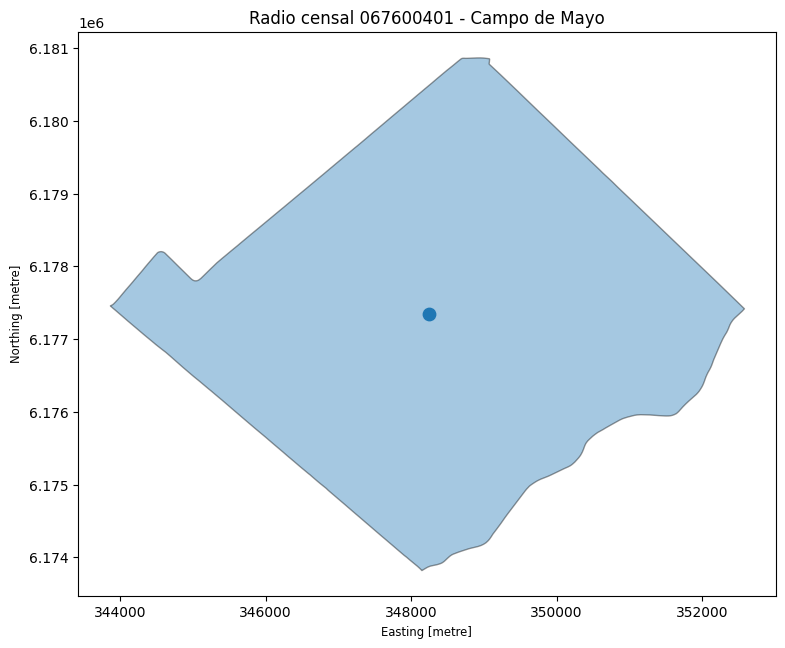

In [118]:
import matplotlib.pyplot as plt
import geopandas as gpd

campo = radios[
    radios["clave"].astype(str) == "067600401"
].copy()

campo = campo.to_crs(radios_m.crs)

punto_campo = campo.copy()
punto_campo["geometry"] = campo.representative_point()

ax = campo.plot(
    figsize=(9,9),
    edgecolor="black",
    alpha=0.4
)

punto_campo.plot(
    ax=ax,
    markersize=80
)

plt.title("Radio censal 067600401 - Campo de Mayo")
plt.show()

In [119]:
pob_total_328 = cobertura_sm["total_redatam"].sum()

pob_excluida = cobertura_sm.loc[
    cobertura_sm["CRO"].isin(["067600401", "067602805"]),
    "total_redatam"
].sum()

pob_326 = pob_total_328 - pob_excluida

print("Población 328 radios:", pob_total_328)
print("Población 326 radios:", pob_326)
print("Población excluida:", pob_excluida)
print("Cobertura del análisis:", pob_326 / pob_total_328 * 100)


Población 328 radios: 327650
Población 326 radios: 326091
Población excluida: 1559
Cobertura del análisis: 99.52418739508622


## 7. Integración de accesibilidad y necesidad potencial

Cruce de la cobertura de salud con los indicadores territoriales de accesibilidad.


In [120]:
acceso_primaria_red["CRO"] = acceso_primaria_red["CRO"].astype(str)
cobertura_sm["CRO"] = cobertura_sm["CRO"].astype(str)

# Porcentaje sin cobertura
cobertura_sm["pct_sin_cobertura"] = (
    cobertura_sm["sin_cobertura"] /
    cobertura_sm["total_redatam"] * 100
)

# Cruzar accesibilidad + cobertura de salud
acceso_necesidad = acceso_primaria_red.merge(
    cobertura_sm[
        [
            "CRO",
            "con_obra_social",
            "plan_estatal",
            "sin_cobertura",
            "total_redatam",
            "pct_sin_cobertura"
        ]
    ],
    on="CRO",
    how="left",
    validate="one_to_one"
)

print("Dimensiones:", acceso_necesidad.shape)

print("\nFaltantes:")
print(
    acceso_necesidad[
        ["total_redatam", "sin_cobertura", "pct_sin_cobertura"]
    ].isna().sum()
)

display(acceso_necesidad.head())

Dimensiones: (326, 11)

Faltantes:
total_redatam        0
sin_cobertura        0
pct_sin_cobertura    0
dtype: int64


,CRO,barrio_nombre,poblacion,centro_primario_mas_cercano,distancia_primaria_vial_km,mas_2km,con_obra_social,plan_estatal,sin_cobertura,total_redatam,pct_sin_cobertura
0,067603004,Trujui,704.0,Centro de Salud Dr. Rene Favaloro (ex Trujui),1.060812,False,475,14.0,215,704,30.539773
1,067601106,Parque San Miguel,968.0,Centro de Salud UFO,0.634359,False,673,22.0,273,968,28.202479
2,067601901,Maria Rosa Mistica,1397.0,Centro de Salud Padre Mora,0.985440,False,975,33.0,389,1397,27.845383
3,067600902,San Miguel Norte,737.0,Centro de Salud Padre Mora,1.993454,False,498,13.0,226,737,30.664858
4,067602510,Santa Anita,843.0,Centro de Salud UFO,0.973511,False,715,6.0,122,843,14.472123


In [121]:
acceso_necesidad["pct_sin_cobertura"].describe()

,pct_sin_cobertura
count,326.000000
mean,32.334169
std,16.622235
min,2.958580
25%,17.914166
50%,29.925942
75%,43.985768
max,76.902887


In [122]:
total = acceso_necesidad["total_redatam"].sum()
sin_cob = acceso_necesidad["sin_cobertura"].sum()

print("Población analizada:", total)
print("Personas sin cobertura:", sin_cob)
print("Porcentaje:", sin_cob / total * 100)

Población analizada: 326091
Personas sin cobertura: 116826
Porcentaje: 35.826195755172634


In [123]:
cobertura_barrios = (
    acceso_necesidad
    .groupby("barrio_nombre")
    .agg(
        poblacion=("total_redatam", "sum"),
        sin_cobertura=("sin_cobertura", "sum"),
        radios=("CRO", "count")
    )
)

cobertura_barrios["pct_sin_cobertura"] = (
    cobertura_barrios["sin_cobertura"] /
    cobertura_barrios["poblacion"] * 100
)

cobertura_barrios = cobertura_barrios.sort_values(
    "pct_sin_cobertura",
    ascending=False
)

display(cobertura_barrios)

,poblacion,sin_cobertura,radios,pct_sin_cobertura
barrio_nombre,,,,
Parque La Luz,8118,5126,5,63.143631
San Ambrosio,5976,3543,4,59.287149
Cuartel 2do Candido Castello,1635,963,1,58.899083
Mitre,17429,10104,14,57.972345
Obligado,19299,10424,17,54.013161
La Estrella,7638,4012,5,52.526839
Barrufaldi,5920,3004,6,50.743243
Santa Brigida,19125,9425,17,49.281046
Lomas de Marilo,4579,2166,3,47.302905


In [124]:
total = acceso_necesidad["total_redatam"].sum()
sin_cob = acceso_necesidad["sin_cobertura"].sum()

print(f"Población analizada: {total:,}")
print(f"Población sin cobertura: {sin_cob:,}")
print(f"% sin cobertura: {sin_cob / total * 100:.2f}%")

print("\nDistribución por radio:")
print(acceso_necesidad["pct_sin_cobertura"].describe())

Población analizada: 326,091
Población sin cobertura: 116,826
% sin cobertura: 35.83%

Distribución por radio:
count    326.000000
mean      32.334169
std       16.622235
min        2.958580
25%       17.914166
50%       29.925942
75%       43.985768
max       76.902887
Name: pct_sin_cobertura, dtype: float64


In [125]:
mapa_necesidad = san_miguel_completo.merge(
    cobertura_sm[
        ["CRO", "sin_cobertura", "total_redatam", "pct_sin_cobertura"]
    ],
    on="CRO",
    how="inner"
)

print("Radios:", len(mapa_necesidad))
print("Faltantes:", mapa_necesidad["pct_sin_cobertura"].isna().sum())

Radios: 326
Faltantes: 0


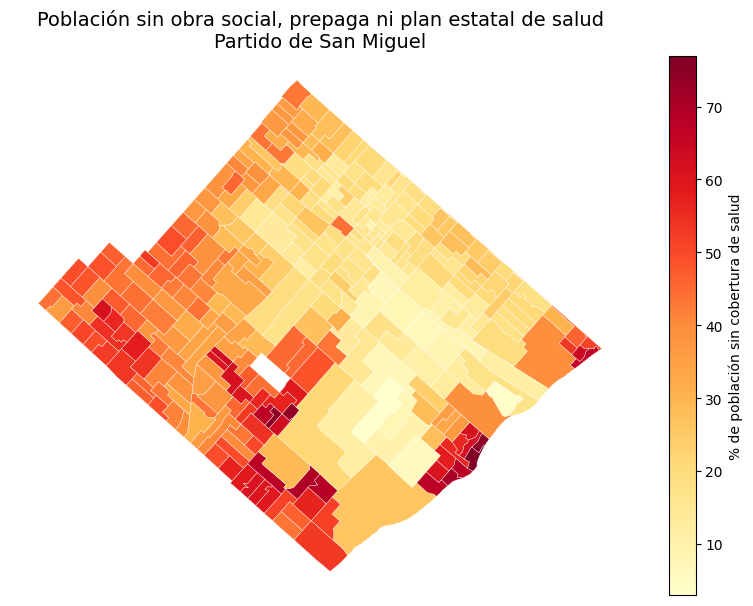

In [126]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

mapa_necesidad.plot(
    column="pct_sin_cobertura",
    cmap="YlOrRd",
    linewidth=0.25,
    edgecolor="white",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "% de población sin cobertura de salud",
        "shrink": 0.7
    }
)

ax.set_title(
    "Población sin obra social, prepaga ni plan estatal de salud\n"
    "Partido de San Miguel",
    fontsize=14
)

ax.axis("off")
plt.show()

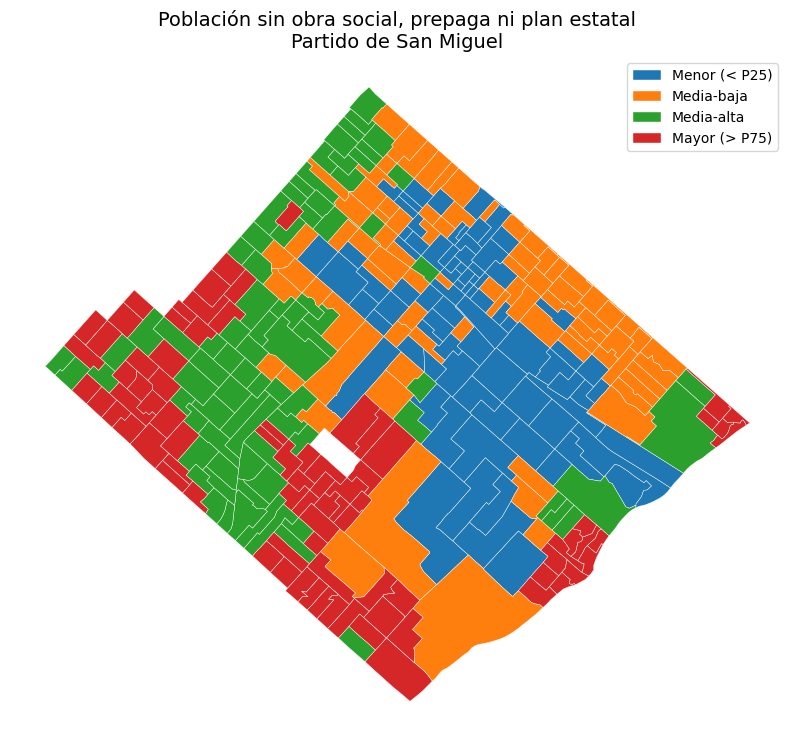

In [127]:
import pandas as pd
import matplotlib.pyplot as plt

# Categorías por cuartiles
mapa_necesidad["categoria_cobertura"] = pd.qcut(
    mapa_necesidad["pct_sin_cobertura"],
    q=4,
    labels=[
        "Menor (< P25)",
        "Media-baja",
        "Media-alta",
        "Mayor (> P75)"
    ]
)

fig, ax = plt.subplots(figsize=(10, 10))

mapa_necesidad.plot(
    column="categoria_cobertura",
    categorical=True,
    legend=True,
    linewidth=0.3,
    edgecolor="white",
    ax=ax
)

ax.set_title(
    "Población sin obra social, prepaga ni plan estatal\n"
    "Partido de San Miguel",
    fontsize=14
)

ax.axis("off")
plt.show()

In [128]:
analisis = acceso_necesidad[
    ["CRO", "barrio_nombre", "poblacion",
     "pct_sin_cobertura", "distancia_primaria_vial_km"]
].copy()

analisis[
    ["pct_sin_cobertura", "distancia_primaria_vial_km"]
].corr(method="spearman")

,pct_sin_cobertura,distancia_primaria_vial_km
pct_sin_cobertura,1.000000,-0.489397
distancia_primaria_vial_km,-0.489397,1.000000


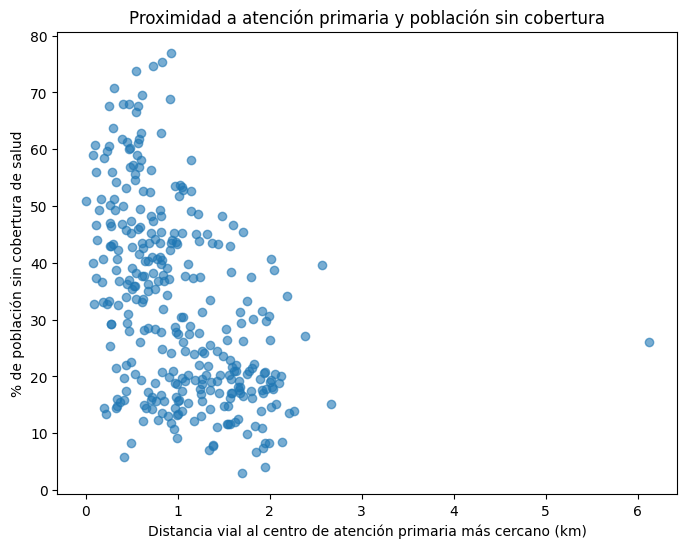

In [129]:
plt.figure(figsize=(8,6))

plt.scatter(
    analisis["distancia_primaria_vial_km"],
    analisis["pct_sin_cobertura"],
    alpha=0.6
)

plt.xlabel("Distancia vial al centro de atención primaria más cercano (km)")
plt.ylabel("% de población sin cobertura de salud")
plt.title("Proximidad a atención primaria y población sin cobertura")

plt.show()

## 8. Asociación estadística

Correlaciones de Spearman entre necesidad potencial y distancia vial.


In [130]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    analisis["distancia_primaria_vial_km"],
    analisis["pct_sin_cobertura"]
)

print(f"Spearman rho = {rho:.3f}")
print(f"p-value = {p_value:.6f}")

Spearman rho = -0.489
p-value = 0.000000


In [131]:
q75_necesidad = analisis["pct_sin_cobertura"].quantile(0.75)
q75_distancia = analisis["distancia_primaria_vial_km"].quantile(0.75)

criticos = analisis[
    (analisis["pct_sin_cobertura"] > q75_necesidad) &
    (analisis["distancia_primaria_vial_km"] > q75_distancia)
].copy()

print("Umbral necesidad:", q75_necesidad)
print("Umbral distancia:", q75_distancia)
print("Radios:", len(criticos))
print("Población:", criticos["poblacion"].sum())

criticos.sort_values(
    ["pct_sin_cobertura", "distancia_primaria_vial_km"],
    ascending=False
)[
    ["CRO", "barrio_nombre", "poblacion",
     "pct_sin_cobertura", "distancia_primaria_vial_km"]
]

Umbral necesidad: 43.985768104157856
Umbral distancia: 1.4800246738361065
Radios: 3
Población: 3082.0


,CRO,barrio_nombre,poblacion,pct_sin_cobertura,distancia_primaria_vial_km
140,067602803,Muniz Oeste,1341.0,48.322148,1.487316
301,067601701,Sarmiento,811.0,46.609125,1.601390
157,067601005,Santa Anita,930.0,45.483871,1.707926


In [132]:
from scipy.stats import spearmanr

# Unir necesidad con distancia al hospital general
analisis_hospital = acceso_necesidad[
    ["CRO", "barrio_nombre", "poblacion", "pct_sin_cobertura"]
].merge(
    acceso_red[
        ["CRO", "distancia_vial_min_km"]
    ],
    on="CRO",
    how="inner"
)

rho_h, p_h = spearmanr(
    analisis_hospital["distancia_vial_min_km"],
    analisis_hospital["pct_sin_cobertura"]
)

print(f"Spearman rho = {rho_h:.3f}")
print(f"p-value = {p_h:.6f}")

Spearman rho = 0.239
p-value = 0.000013


In [133]:
q75_nec = analisis_hospital["pct_sin_cobertura"].quantile(.75)
q75_dist_h = analisis_hospital["distancia_vial_min_km"].quantile(.75)

alta_necesidad_alta_dist_hospital = analisis_hospital[
    (analisis_hospital["pct_sin_cobertura"] > q75_nec) &
    (analisis_hospital["distancia_vial_min_km"] > q75_dist_h)
].sort_values("distancia_vial_min_km", ascending=False)

alta_necesidad_alta_dist_hospital

,CRO,barrio_nombre,poblacion,pct_sin_cobertura,distancia_vial_min_km
90,067602911,Bella Vista Oeste,1287.0,52.758353,5.526057
65,067603205,Lomas de Marilo,1351.0,46.484086,4.885864
295,067602910,Parque La Luz,1565.0,51.693291,4.770421
289,067602908,Obligado,2275.0,67.604396,4.504424
202,067603203,Parque La Luz,1564.0,56.841432,4.496389
28,067603204,Lomas de Marilo,1702.0,51.292597,4.348188
44,067603106,San Ambrosio,1644.0,59.002433,4.222495
22,067603202,Parque La Luz,1678.0,68.772348,4.159061
201,067603201,Parque La Luz,1606.0,69.489415,4.153717
66,067602905,Obligado,709.0,70.803949,4.097587


In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# ATENCIÓN PRIMARIA
# =========================

biv_primaria = acceso_necesidad[
    ["CRO", "barrio_nombre", "poblacion", "pct_sin_cobertura"]
].merge(
    acceso_primaria_red[
        ["CRO", "distancia_primaria_vial_km"]
    ],
    on="CRO",
    how="inner"
)

# =========================
# HOSPITALES GENERALES
# =========================

biv_hospital = acceso_necesidad[
    ["CRO", "barrio_nombre", "poblacion", "pct_sin_cobertura"]
].merge(
    acceso_red[
        ["CRO", "distancia_vial_min_km"]
    ],
    on="CRO",
    how="inner"
)

print("Primaria:", len(biv_primaria))
print("Hospital:", len(biv_hospital))

Primaria: 326
Hospital: 326


## 9. Mapas bivariados

Clasificación relativa mediante terciles de necesidad potencial y distancia.


In [135]:
# Cortes comunes de necesidad
q_nec = acceso_necesidad["pct_sin_cobertura"].quantile([1/3, 2/3])

nec_1 = q_nec.iloc[0]
nec_2 = q_nec.iloc[1]

print("Necesidad:")
print(f"Baja: <= {nec_1:.2f}%")
print(f"Media: {nec_1:.2f}% - {nec_2:.2f}%")
print(f"Alta: > {nec_2:.2f}%")

# Terciles de distancia específicos de cada nivel de atención
q_prim = biv_primaria["distancia_primaria_vial_km"].quantile([1/3, 2/3])
q_hosp = biv_hospital["distancia_vial_min_km"].quantile([1/3, 2/3])

print("\nDistancia atención primaria:")
print(q_prim)

print("\nDistancia hospital:")
print(q_hosp)

Necesidad:
Baja: <= 20.30%
Media: 20.30% - 40.19%
Alta: > 40.19%

Distancia atención primaria:
0.333333    0.63437
0.666667    1.24101
Name: distancia_primaria_vial_km, dtype: float64

Distancia hospital:
0.333333    1.671188
0.666667    2.476717
Name: distancia_vial_min_km, dtype: float64


In [136]:
def clasificar_3(valor, q1, q2):
    if valor <= q1:
        return 0   # bajo
    elif valor <= q2:
        return 1   # medio
    else:
        return 2   # alto


# Necesidad
for df in [biv_primaria, biv_hospital]:
    df["necesidad"] = df["pct_sin_cobertura"].apply(
        lambda x: clasificar_3(x, nec_1, nec_2)
    )


# Distancia primaria
biv_primaria["distancia_cat"] = biv_primaria[
    "distancia_primaria_vial_km"
].apply(
    lambda x: clasificar_3(
        x,
        q_prim.iloc[0],
        q_prim.iloc[1]
    )
)


# Distancia hospitalaria
biv_hospital["distancia_cat"] = biv_hospital[
    "distancia_vial_min_km"
].apply(
    lambda x: clasificar_3(
        x,
        q_hosp.iloc[0],
        q_hosp.iloc[1]
    )
)


# Código bivariado
# Ejemplo: "2-2" = necesidad alta + distancia alta

biv_primaria["bivar"] = (
    biv_primaria["necesidad"].astype(str)
    + "-"
    + biv_primaria["distancia_cat"].astype(str)
)

biv_hospital["bivar"] = (
    biv_hospital["necesidad"].astype(str)
    + "-"
    + biv_hospital["distancia_cat"].astype(str)
)

In [137]:
mapa_biv_primaria = san_miguel_completo[
    ["CRO", "geometry"]
].merge(
    biv_primaria,
    on="CRO",
    how="inner"
)

mapa_biv_hospital = san_miguel_completo[
    ["CRO", "geometry"]
].merge(
    biv_hospital,
    on="CRO",
    how="inner"
)

print(len(mapa_biv_primaria), len(mapa_biv_hospital))

326 326


In [138]:
colores = {
    "0-0": "#e8e8e8",  # necesidad baja / distancia baja
    "0-1": "#ace4e4",
    "0-2": "#5ac8c8",

    "1-0": "#dfb0d6",
    "1-1": "#a5add3",
    "1-2": "#5698b9",

    "2-0": "#be64ac",
    "2-1": "#8c62aa",
    "2-2": "#3b4994"   # necesidad alta / distancia alta
}

mapa_biv_primaria["color"] = mapa_biv_primaria["bivar"].map(colores)
mapa_biv_hospital["color"] = mapa_biv_hospital["bivar"].map(colores)

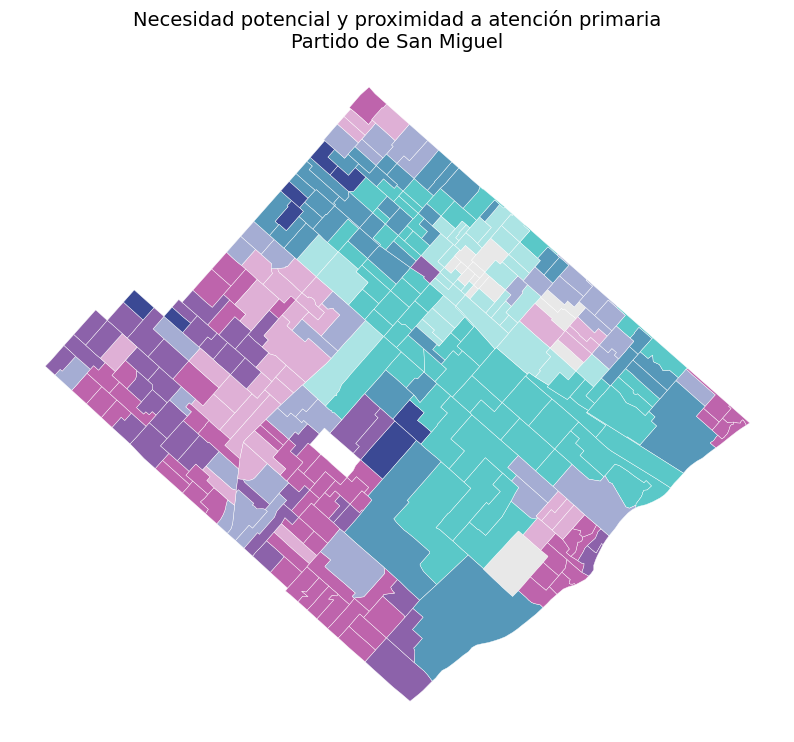

In [139]:
fig, ax = plt.subplots(figsize=(10, 10))

mapa_biv_primaria.plot(
    color=mapa_biv_primaria["color"],
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

ax.set_title(
    "Necesidad potencial y proximidad a atención primaria\n"
    "Partido de San Miguel",
    fontsize=14
)

ax.axis("off")

plt.show()

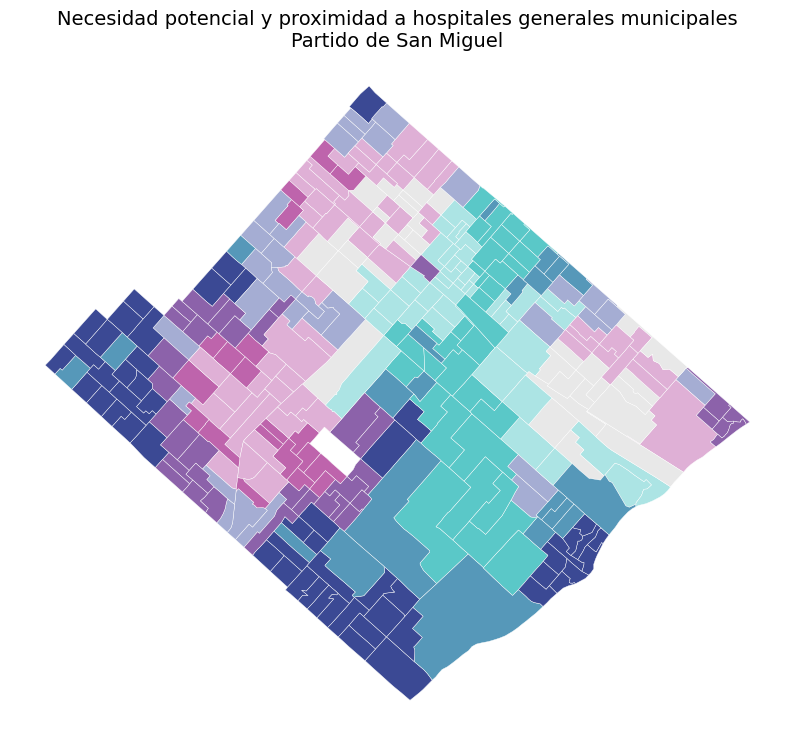

In [140]:
fig, ax = plt.subplots(figsize=(10, 10))

mapa_biv_hospital.plot(
    color=mapa_biv_hospital["color"],
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

ax.set_title(
    "Necesidad potencial y proximidad a hospitales generales municipales\n"
    "Partido de San Miguel",
    fontsize=14
)

ax.axis("off")

plt.show()

In [141]:
# Crear una geometría única por barrio
barrios_labels = (
    san_miguel_completo[
        ["barrio_nombre", "geometry"]
    ]
    .dropna(subset=["barrio_nombre"])
    .dissolve(by="barrio_nombre")
    .reset_index()
)

# Punto representativo dentro de cada barrio
barrios_labels["label_point"] = (
    barrios_labels.geometry.representative_point()
)

print("Barrios:", len(barrios_labels))

Barrios: 39


In [142]:
from matplotlib.patches import Rectangle

def agregar_leyenda_bivariada(fig):

    # Posición de la leyenda dentro de la figura
    ax_leg = fig.add_axes([0.76, 0.13, 0.17, 0.17])

    matriz = [
        ["0-0", "0-1", "0-2"],
        ["1-0", "1-1", "1-2"],
        ["2-0", "2-1", "2-2"]
    ]

    # Dibujar cuadrados
    for fila in range(3):
        for col in range(3):

            codigo = matriz[fila][col]

            ax_leg.add_patch(
                Rectangle(
                    (col, fila),
                    1,
                    1,
                    facecolor=colores[codigo],
                    edgecolor="white"
                )
            )

    ax_leg.set_xlim(0, 3)
    ax_leg.set_ylim(0, 3)

    ax_leg.set_xticks([0.5, 1.5, 2.5])
    ax_leg.set_xticklabels(
        ["Baja", "Media", "Alta"],
        fontsize=7
    )

    ax_leg.set_yticks([0.5, 1.5, 2.5])
    ax_leg.set_yticklabels(
        ["Baja", "Media", "Alta"],
        fontsize=7
    )

    ax_leg.set_xlabel(
        "Distancia",
        fontsize=8
    )

    ax_leg.set_ylabel(
        "Necesidad potencial",
        fontsize=8
    )

    ax_leg.tick_params(length=0)

    for spine in ax_leg.spines.values():
        spine.set_visible(False)

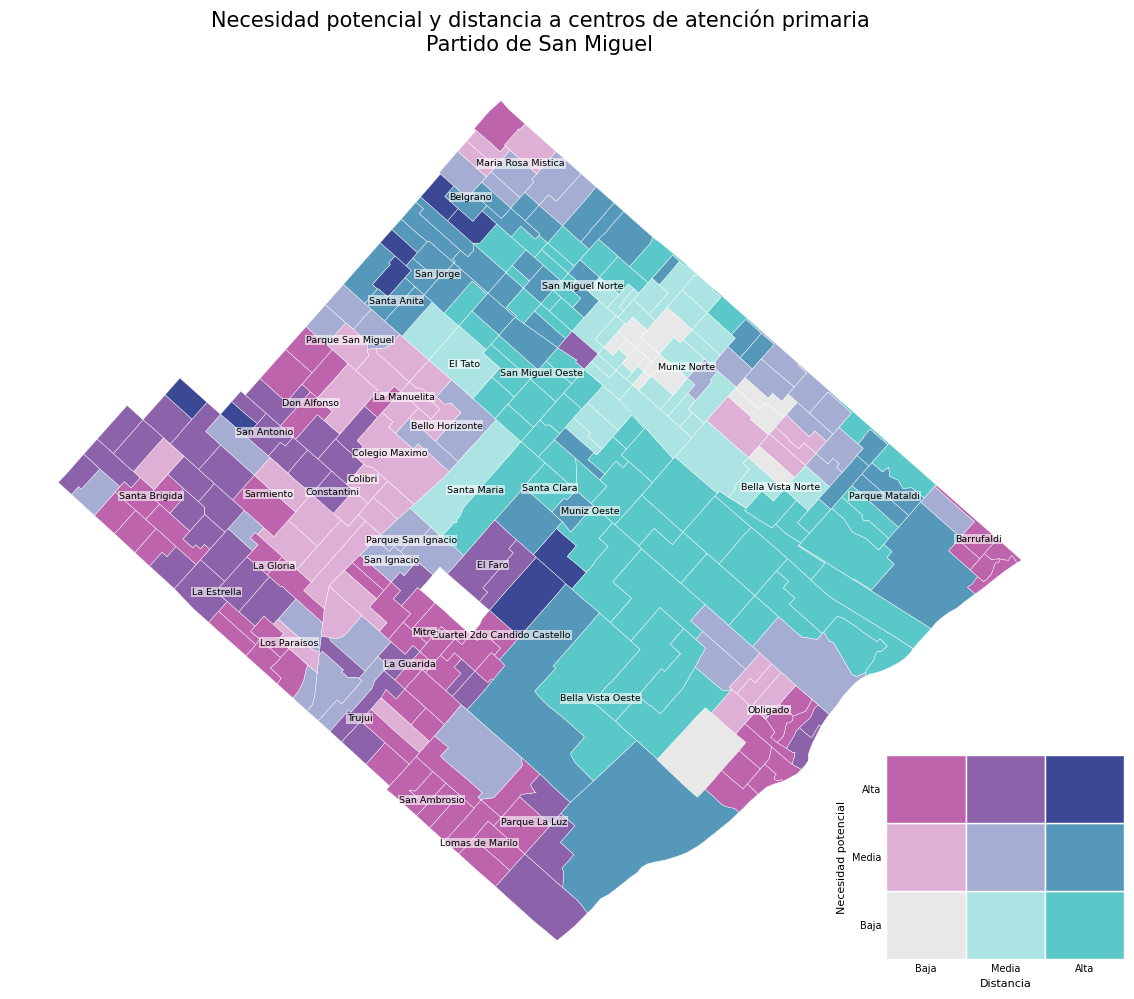

In [143]:
fig, ax = plt.subplots(figsize=(14, 12))

mapa_biv_primaria.plot(
    color=mapa_biv_primaria["color"],
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

# TODOS los barrios
for _, row in barrios_labels.iterrows():

    x = row["label_point"].x
    y = row["label_point"].y

    ax.annotate(
        row["barrio_nombre"],
        xy=(x, y),
        ha="center",
        va="center",
        fontsize=6.8,
        color="black",
        bbox=dict(
            facecolor="white",
            alpha=0.60,
            edgecolor="none",
            pad=0.5
        )
    )

ax.set_title(
    "Necesidad potencial y distancia a centros de atención primaria\n"
    "Partido de San Miguel",
    fontsize=15
)

ax.axis("off")

agregar_leyenda_bivariada(fig)

plt.show()

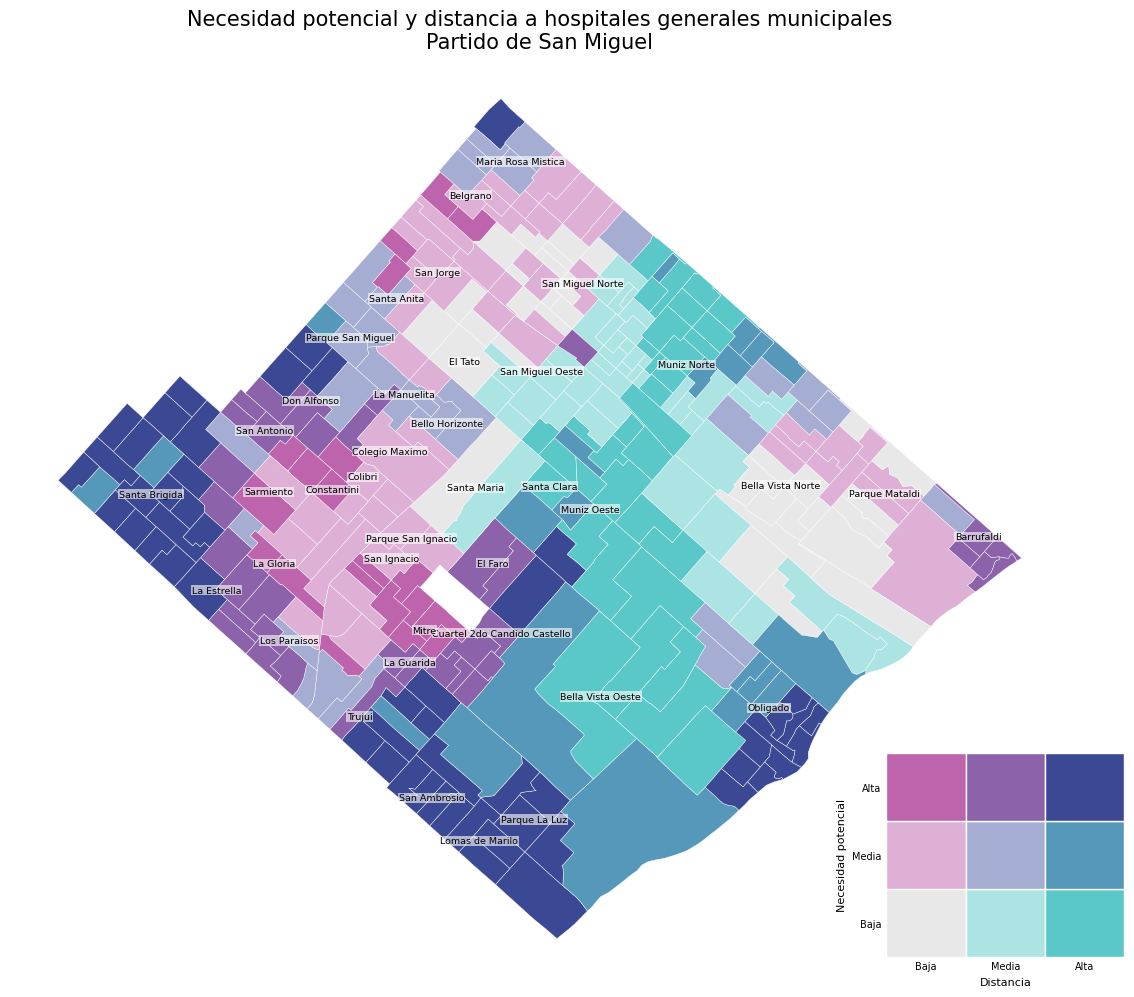

In [144]:
fig, ax = plt.subplots(figsize=(14, 12))

mapa_biv_hospital.plot(
    color=mapa_biv_hospital["color"],
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

# TODOS los barrios
for _, row in barrios_labels.iterrows():

    x = row["label_point"].x
    y = row["label_point"].y

    ax.annotate(
        row["barrio_nombre"],
        xy=(x, y),
        ha="center",
        va="center",
        fontsize=6.8,
        color="black",
        bbox=dict(
            facecolor="white",
            alpha=0.60,
            edgecolor="none",
            pad=0.5
        )
    )

ax.set_title(
    "Necesidad potencial y distancia a hospitales generales municipales\n"
    "Partido de San Miguel",
    fontsize=15
)

ax.axis("off")

agregar_leyenda_bivariada(fig)

plt.show()